<a href="https://colab.research.google.com/github/nkcrooks/Movie-Analysis---Python/blob/main/Me_vs_Taylor_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigating my IMDb Ratings

**Questions to investigate**
> What has the biggest predictor of my user ratings? Popularity, critical rewards, box office success or IMDb rating?  
Do my habits change over time?  
Do the movies I like predict the shows/games/books I like?

**Project Aim**
> Display data analysis skill in the main python packages

## Loading Data and Packages

In [ ]:
from google.colab import drive
# drive.mount('/content/drive')
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Packages
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mpl_dates
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
from matplotlib.ticker import FuncFormatter
# from itertools import cycle

# import matplotlib as mpl
# name = "Accent"
# cmap = mpl.colormaps[name]  # type: matplotlib.colors.ListedColormap
# colors = cmap.colors  # type: list

# colours = cycle(['red', 'green', 'blue'])

In [ ]:
# Load data
# Set folder path
folder_path = Path('/content/drive/My Drive/Datasets/Python/Trakt Project')

# Get all CSV and JSON files
csv_files = list(folder_path.glob('*.csv'))
json_files = list(folder_path.glob('*.json'))

# Read each csv file into a dictionary with file names as keys (without extensions)
csvs = {file.stem: pd.read_csv(file) for file in csv_files}
jsons = {file.stem: pd.read_json(file) for file in json_files}

# Merge the two dictionaries
dfs = {**csvs, **jsons}

print("Keys\n",dfs.keys())

# # Confirm folder contents
print(os.listdir(folder_path))

# Example: Access the DataFrame for a specific file
df = pd.DataFrame(dfs['enriched_movies'])

# Set working directory to the project folder
os.chdir(folder_path)

Keys
 dict_keys(['NetflixViewingHistory With Type(in)', 'the_oscar_award', 'enriched_data', 'enriched_movies', 'cleaned_enriched_movies', 'cleaned_enriched_movies_country', 'cleaned_enriched_movies_genres', 'cleaned_enriched_movies_directors', 'cleaned_enriched_movies_actors'])
['NetflixViewingHistory With Type(in).csv', 'Enrich Netflix Data.ipynb', 'Dashboard.ipynb', 'the_oscar_award.csv', 'enriched_data.csv', 'enriched_movies.csv', 'Enrich Trakt Data.ipynb', 'Prediction.ipynb', 'cleaned_enriched_movies.csv', 'cleaned_enriched_movies_country.csv', 'cleaned_enriched_movies_genres.csv', 'cleaned_enriched_movies_directors.csv', 'cleaned_enriched_movies_actors.csv']


In [ ]:
# Graph Style Settings
print(plt.style.available)
sns.set_theme(context='notebook', style='darkgrid', palette='viridis', font='sans-serif', font_scale=1.25, color_codes=True, rc=None)
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
sns.set_palette('vlag')

# plt.style.use('tableau-colorblind10')
# plt.style.use("dark_background")
# plt.style.use("light_background")
# plt.style.use("seaborn-v0_8-darkgrid")
# plt.style.use("seaborn-v0_8-whitegrid")
# plt.style.use("seaborn-v0_8-colorblind")
plt.style.use("fivethirtyeight")

plt.rcParams.update({
    "figure.facecolor": "#0a0a0a",
    "axes.facecolor": "#0a0a0a",
    "axes.labelcolor": "#f0f0f0",
    "axes.edgecolor": "#444444",
    "xtick.color": "#dddddd",
    "ytick.color": "#dddddd",
    "text.color":   "#dddddd",
    "grid.color":   "#dddddd"
})
# Set colours to cycle
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# DataFrame Settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)
# Decimal places
pd.set_option('display.float_format', '{:.2f}'.format)
# pd.options.display.float_format = '{:.1f}'.format

# Freeze column headers
# .style.set_table_styles([
#     {'selector': 'thead th', 'props': 'position: sticky; top:0; background-color:red;'}
# ])
# pd.options.display.styler.table_styles = [
#     {'selector': 'thead th', 'props': 'position: sticky; top:0; background-color:red;'}
# ]

# Date formate
date_format = mpl_dates.DateFormatter('%b %d, %Y')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


## Shape of the data

In [ ]:
# Preview first 8 rows
print("First 8 Rows:")
display(df.head(8))

# Check shape
print(f"\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Dataset info
print("\nColumn Types & Non-Null Counts:")
display(df.info())

# Describe numerical features
print("\nSummary Statistics (Numerical Columns):")
display(df.describe(include=[np.number]))

# Show object columns with value counts
print("\nSample Categorical Value Counts:")
for col in df.select_dtypes(include="object").columns[:5]:
    print(f"\n{col} ➤")
    print(df[col].value_counts().head(3))

First 8 Rows:


,ids.imdb,viewer,rating,Date Rated,Title,URL,Title Type,IMDb Rating,Runtime (mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,movie,7.30,93.00,1997,"Animation, Action, Adventure","268,256",27 Jun 1997,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,"$99,112,101"
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,movie,7.90,95.00,2025,"Animation, Action, Adventure","1,709",20 Jun 2025,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN,NaN
2,tt37244927,nowell,6,2025-06-28 18:52:35+00:00,Big Man,https://www.imdb.com/title...,movie,5.80,NaN,2025,"Short, Drama, Music",117,18 Jun 2025,Aneil Karia,"Stormzy, Klevis Brahja, Ja...",English,United Kingdom,NaN,NaN,NaN
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,movie,6.90,32.00,2020,"Short, Drama, Sci-Fi","21,920",20 Nov 2020,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,movie,7.20,120.00,2014,"Comedy, Drama","69,765",30 Dec 2014,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,"$1,359,497"
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,movie,6.50,97.00,2025,Comedy,"14,129",17 Jan 2025,Lawrence Lamont,"Keke Palmer, SZA, Vanessa ...",English,United States,NaN,71.00,"$50,054,690"
6,tt1130884,nowell,5,2025-06-03 19:43:59+00:00,Shutter Island,https://www.imdb.com/title...,movie,8.20,138.00,2010,"Drama, Mystery, Thriller","1,563,854",19 Feb 2010,Martin Scorsese,"Leonardo DiCaprio, Emily M...","English, German","United States, Canada",11 wins & 66 nominations t...,63.00,"$128,012,934"
7,tt5083738,nowell,8,2025-06-01 18:31:40+00:00,The Favourite,https://www.imdb.com/title...,movie,7.50,119.00,2018,"Biography, Comedy, Drama","247,322",21 Dec 2018,Yorgos Lanthimos,"Olivia Colman, Emma Stone,...",English,"Ireland, United Kingdom, U...",Won 1 Oscar. 188 wins & 35...,91.00,"$34,366,783"



Dataset contains 424 rows and 20 columns.

Column Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ids.imdb        424 non-null    object 
 1   viewer          424 non-null    object 
 2   rating          424 non-null    int64  
 3   Date Rated      424 non-null    object 
 4   Title           424 non-null    object 
 5   URL             424 non-null    object 
 6   Title Type      424 non-null    object 
 7   IMDb Rating     424 non-null    float64
 8   Runtime (mins)  423 non-null    float64
 9   Release Year    424 non-null    int64  
 10  Genres          424 non-null    object 
 11  Num Votes       424 non-null    object 
 12  Release Date    424 non-null    object 
 13  Directors       424 non-null    object 
 14  Actors          424 non-null    object 
 15  Language        424 non-null    object 
 16  Coun

,rating,IMDb Rating,Runtime (mins),Release Year,Metascore
count,424.00,424.00,423.00,424.00,407.00
mean,6.43,7.26,115.67,2011.73,69.30
std,1.58,0.85,23.90,13.45,14.06
min,1.00,2.80,25.00,1950.00,22.00
25%,6.00,6.80,99.00,2005.00,61.00
50%,7.00,7.30,113.00,2016.00,71.00
75%,7.25,7.90,130.00,2021.00,79.50
max,10.00,9.20,206.00,2025.00,100.00



Sample Categorical Value Counts:

ids.imdb ➤
ids.imdb
tt0317705    2
tt3480822    2
tt1899353    2
Name: count, dtype: int64

viewer ➤
viewer
nowell    291
taylor    133
Name: count, dtype: int64

Date Rated ➤
Date Rated
2023-06-11 00:00:00+00:00    5
2021-06-11 00:00:00+00:00    4
2020-12-16 00:00:00+00:00    4
Name: count, dtype: int64

Title ➤
Title
The Incredibles         2
Black Widow             2
The Raid: Redemption    2
Name: count, dtype: int64

URL ➤
URL
https://www.imdb.com/title/tt0317705/    2
https://www.imdb.com/title/tt3480822/    2
https://www.imdb.com/title/tt1899353/    2
Name: count, dtype: int64


In [ ]:
df_cat = df.select_dtypes(include={'category', 'object'}, exclude='number')
df_num = df.select_dtypes(include="number")
display(df_cat.head())
display(df_num.head())

,ids.imdb,viewer,Date Rated,Title,URL,Title Type,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Box Office
0,tt0119282,nowell,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,movie,"Animation, Action, Adventure","268,256",27 Jun 1997,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,"$99,112,101"
1,tt14205554,nowell,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,movie,"Animation, Action, Adventure","1,709",20 Jun 2025,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN
2,tt37244927,nowell,2025-06-28 18:52:35+00:00,Big Man,https://www.imdb.com/title...,movie,"Short, Drama, Music",117,18 Jun 2025,Aneil Karia,"Stormzy, Klevis Brahja, Ja...",English,United Kingdom,NaN,NaN
3,tt13472984,nowell,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,movie,"Short, Drama, Sci-Fi","21,920",20 Nov 2020,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN
4,tt2121382,nowell,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,movie,"Comedy, Drama","69,765",30 Dec 2014,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,"$1,359,497"


,rating,IMDb Rating,Runtime (mins),Release Year,Metascore
0,6,7.30,93.00,1997,74.00
1,7,7.90,95.00,2025,NaN
2,6,5.80,NaN,2025,NaN
3,6,6.90,32.00,2020,NaN
4,3,7.20,120.00,2014,87.00


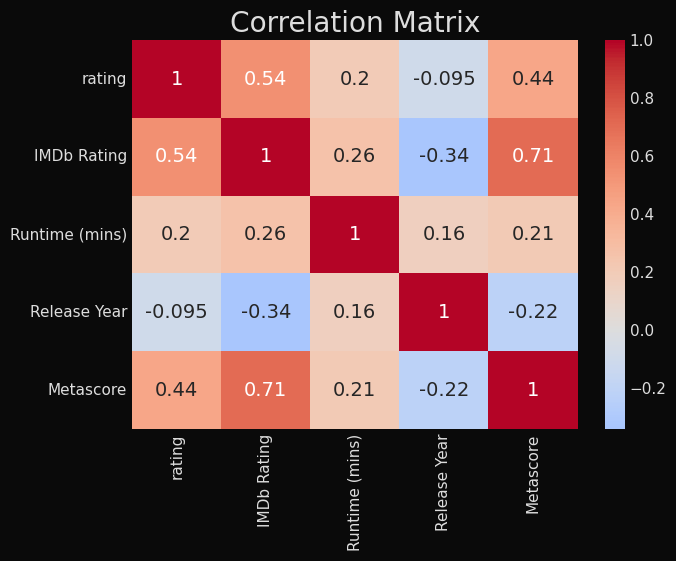

In [ ]:
corr_matrix = df_num.corr(numeric_only = True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

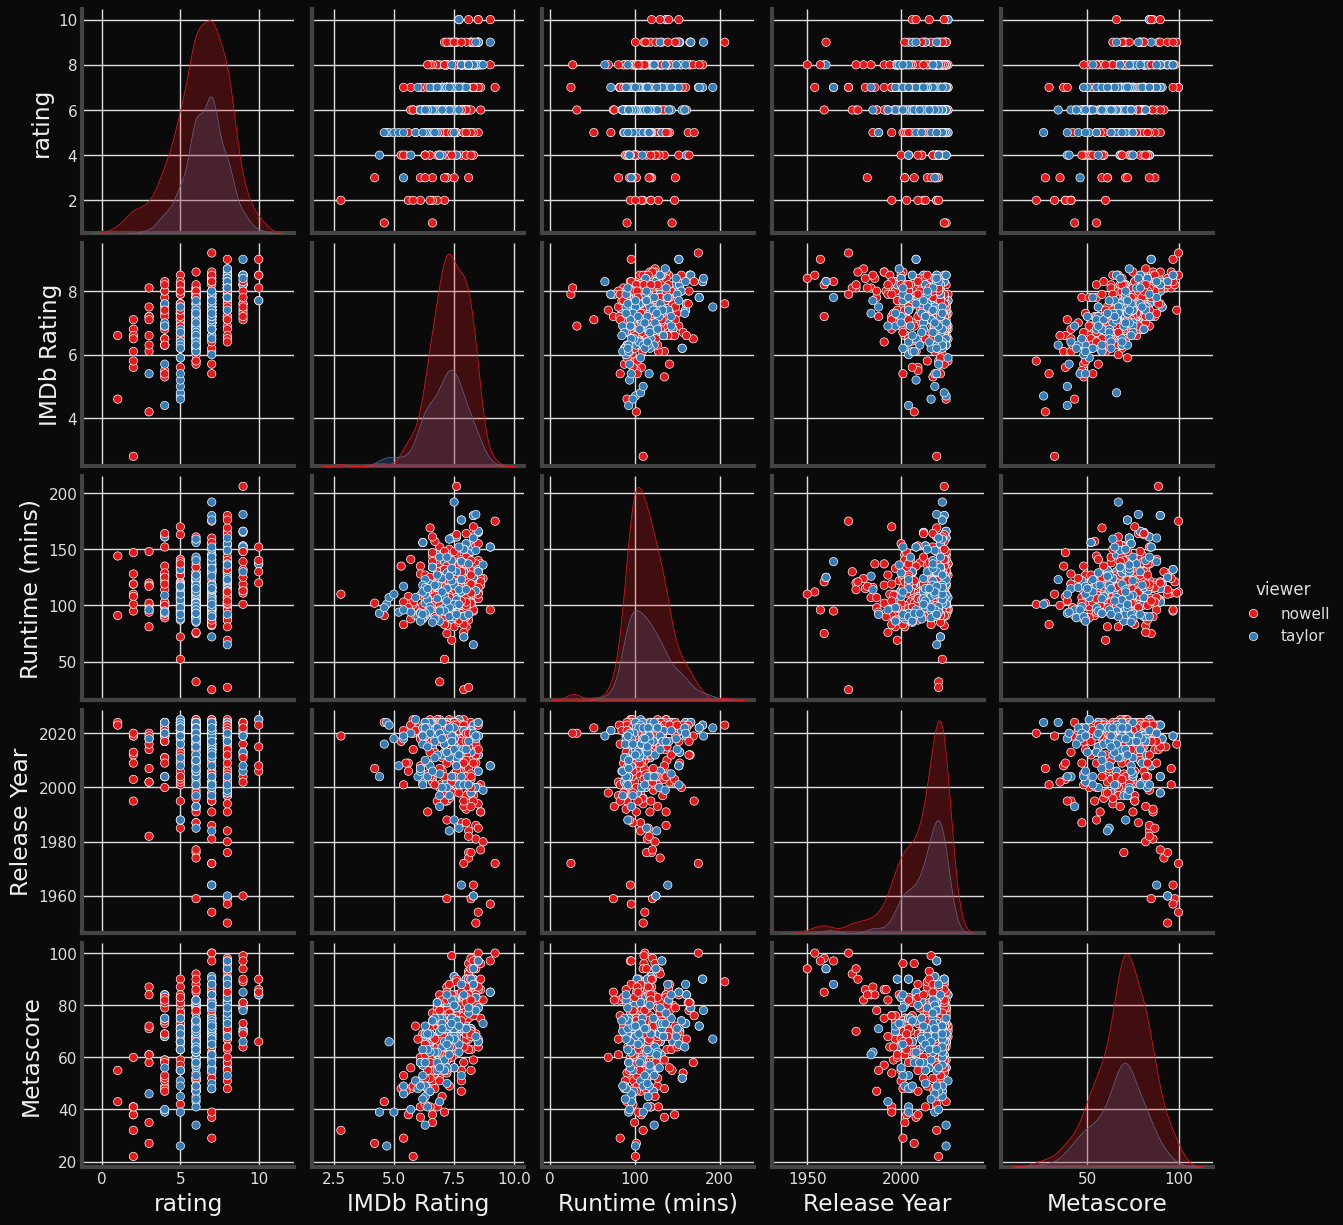

In [ ]:
sns.pairplot(df, hue='viewer')

<Axes: xlabel='Title Type', ylabel='count'>

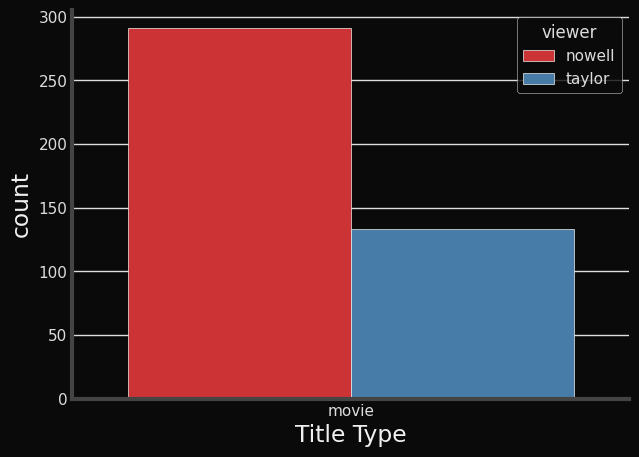

In [ ]:
sns.countplot(df, x='Title Type', hue='viewer')

## Data Cleaning


### Data Types

In [ ]:
# Remove Series and games as only looking at movies now
display(df['Title Type'].unique())
df = df[df['Title Type']=='movie']

array(['movie'], dtype=object)

In [ ]:
# Changing types to datatime
df['Date Rated']= pd.to_datetime(df['Date Rated'])
df['Release Date']= pd.to_datetime(df['Release Date'])
df['Release Year']= pd.to_datetime(df['Release Year'], format='%Y')
df['Release Year'] = df['Release Year'].dt.year
df['Runtime (mins)'] = pd.to_numeric(df['Runtime (mins)'], errors='coerce').astype('Int64')

In [ ]:
# Changing numerics to int
df['Num Votes'] = df['Num Votes'].str.replace(',', '').astype(int)
df['Box Office'] = df['Box Office'].str.replace(',', '').str.replace('$', '').astype(float)
display(df.dtypes)
display(df.info())

,0
ids.imdb,object
viewer,object
rating,int64
Date Rated,"datetime64[ns, UTC]"
Title,object
URL,object
Title Type,object
IMDb Rating,float64
Runtime (mins),Int64
Release Year,int32


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   ids.imdb        424 non-null    object             
 1   viewer          424 non-null    object             
 2   rating          424 non-null    int64              
 3   Date Rated      424 non-null    datetime64[ns, UTC]
 4   Title           424 non-null    object             
 5   URL             424 non-null    object             
 6   Title Type      424 non-null    object             
 7   IMDb Rating     424 non-null    float64            
 8   Runtime (mins)  423 non-null    Int64              
 9   Release Year    424 non-null    int32              
 10  Genres          424 non-null    object             
 11  Num Votes       424 non-null    int64              
 12  Release Date    424 non-null    datetime64[ns]     
 13  Directors       424 non-null    obj

None

### Columns Structure

In [ ]:
# Standardise columns
df.drop(columns=['Title Type'], inplace = True)
df.columns = [col.title() for col in df.columns]
df.rename(columns={'Rating':'User Rating','Imdb Rating': 'IMDb Rating', 'Ids.Imdb':'ids.imdb'}, inplace=True)
df.columns

Index(['ids.imdb', 'Viewer', 'User Rating', 'Date Rated', 'Title', 'Url',
       'IMDb Rating', 'Runtime (Mins)', 'Release Year', 'Genres', 'Num Votes',
       'Release Date', 'Directors', 'Actors', 'Language', 'Country', 'Awards',
       'Metascore', 'Box Office'],
      dtype='object')

### Duplicate and Null Values

In [ ]:
print("Duplicates", df.duplicated().sum())
print("Nulls\n", df.isnull().sum())

Duplicates 0
Nulls
 ids.imdb           0
Viewer             0
User Rating        0
Date Rated         0
Title              0
Url                0
IMDb Rating        0
Runtime (Mins)     1
Release Year       0
Genres             0
Num Votes          0
Release Date       0
Directors          0
Actors             0
Language           0
Country            1
Awards            12
Metascore         17
Box Office        48
dtype: int64


In [ ]:
# df.loc[df['Directors'].isna(),]
# df.loc[df['Directors'].isna(), ['Title', 'Release Year', 'Genres']].head(20)
# df.loc[df['Directors'].isna(), 'Viewer'].value_counts()
# df.loc[df['Directors'].isna(), 'Release Year'].value_counts().sort_index().plot()
# df.loc[df['Directors'].isna(), 'IMDb Rating'].describe()

In [ ]:
# misc =df.loc[df['Runtime (Mins)'].isna()]
# df.drop(misc.index, inplace=True)
df.drop(df.loc[df['Runtime (Mins)'].isna()].index, inplace=True)

## Data Preparation

#### Create new engineered features

#### Date

In [ ]:
# Movie release details
df['Release Decade'] = df['Release Year'] - (df['Release Year'] % 10)
df['Release Season'] = df['Release Date'].dt.quarter
df['Release Month'] = df['Release Date'].dt.month
df['Release Day'] = df['Release Date'].dt.day
df['Release Day of Week'] = df['Release Date'].dt.dayofweek
df.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"Short, Drama, Sci-Fi",21920,2020-11-20,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"Comedy, Drama",69765,2014-12-30,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,6.50,97,2025,Comedy,14129,2025-01-17,Lawrence Lamont,"Keke Palmer, SZA, Vanessa ...",English,United States,NaN,71.00,50054690.00,2020,1,1,17,4


In [ ]:
df['Year Rated'] = df.loc[:,'Date Rated'].dt.year.copy()
df['Month Rated'] = df['Date Rated'].dt.month
df['Season Rated'] = df['Date Rated'].dt.quarter
df['Day Rated'] = df['Date Rated'].dt.day
df['Day of Week Rated'] = df['Date Rated'].dt.dayofweek
df.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker","Tate Donovan, Susan Egan, ...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang","Arden Cho, May Hong, Ji-yo...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"Short, Drama, Sci-Fi",21920,2020-11-20,"Travon Free, Martin Desmon...","Joey Bada$$, Zaria, Vincen...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"Comedy, Drama",69765,2014-12-30,Ruben Östlund,"Johannes Kuhnke, Lisa Love...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,6.50,97,2025,Comedy,14129,2025-01-17,Lawrence Lamont,"Keke Palmer, SZA, Vanessa ...",English,United States,NaN,71.00,50054690.00,2020,1,1,17,4,2025,6,2,11,2


#### Misc features

In [ ]:
# Log reviews for graphing
df['Log Votes'] = np.log(df['Num Votes'])
df['Log Votes'].describe()

,Log Votes
count,423.00
mean,12.40
std,1.32
min,6.21
25%,11.82
50%,12.63
75%,13.30
max,14.93


In [ ]:
df['Box Office Millions'] = df['Box Office'] / 1_000_000
df['Num Votes Thousands'] = df['Num Votes'] / 1_000
display(df['Box Office Millions'].describe())
display(df['Num Votes Thousands'].describe())

,Box Office Millions
count,376.00
mean,141.77
std,156.77
min,0.01
25%,34.50
50%,94.45
75%,183.65
max,936.66


,Num Votes Thousands
count,423.00
mean,440.45
std,447.10
min,0.50
25%,136.56
50%,305.73
75%,595.96
max,3044.55


In [ ]:
taylor = df['Viewer']=='taylor'
nowell = df['Viewer']=='nowell'

In [ ]:
# Rounded IMDb ratings for comparison
df['IMDb Rating Rounded'] = df.loc[:,'IMDb Rating'].round()

In [ ]:
rating_bins = [0, 5.9, 7.9, 10]
rating_labels = ['Low', 'Medium', 'High']
df['Rating_Category'] = pd.cut(df['IMDb Rating'], bins=rating_bins, labels=rating_labels, include_lowest=True)

In [ ]:
df['Primary Genre'] = df['Genres'].str.split(',').str[0]
display(df['Primary Genre'].value_counts())

,count
Primary Genre,
Action,147
Animation,77
Comedy,77
Drama,45
Crime,25
Adventure,18
Biography,15
Horror,12
Short,2


#### Exploding list columns

In [ ]:
df['Actors'] = df['Actors'].fillna('').apply(lambda x: [actor.strip() for actor in x.split(',')])

df_actors = df.explode('Actors').reset_index(drop=True)
df_actors.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Half Decade,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker",Tate Donovan,"English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
1,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker",Susan Egan,"English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
2,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,"Ron Clements, John Musker",James Woods,"English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
3,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang",Arden Cho,"English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
4,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,"Chris Appelhans, Maggie Kang",May Hong,"English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation


In [ ]:
# Remove spaces and split by comma
df['Directors'] = df['Directors'].fillna('').apply(lambda x: [director.strip() for director in x.split(',')])
# Exploding directors
df_directors = df.explode('Directors').reset_index(drop=True)
df_directors.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Half Decade,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,Ron Clements,"[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
1,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"Animation, Action, Adventure",268256,1997-06-27,John Musker,"[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
2,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,Chris Appelhans,"[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
3,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"Animation, Action, Adventure",1709,2025-06-20,Maggie Kang,"[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
4,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"Short, Drama, Sci-Fi",21920,2020-11-20,Travon Free,"[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,"(2015, 2020]",10.00,NaN,21.92,7.00,Medium,Short


Exploding genres

In [ ]:
# Remove spaces and split by comma
df['Genres'] = df['Genres'].fillna('').apply(lambda x: [genre.strip() for genre in x.split(',')])
df.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Half Decade,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"[Animation, Action, Advent...",268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"[Animation, Action, Advent...",1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
3,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"[Short, Drama, Sci-Fi]",21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,"(2015, 2020]",10.00,NaN,21.92,7.00,Medium,Short
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"[Comedy, Drama]",69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,"(2010, 2015]",11.15,1.36,69.77,7.00,Medium,Comedy
5,tt32221196,nowell,7,2025-06-11 23:26:44+00:00,One of Them Days,https://www.imdb.com/title...,6.50,97,2025,[Comedy],14129,2025-01-17,[Lawrence Lamont],"[Keke Palmer, SZA, Vanessa...",English,United States,NaN,71.00,50054690.00,2020,1,1,17,4,2025,6,2,11,2,"(2020, 2025]",9.56,50.05,14.13,6.00,Medium,Comedy


In [ ]:
# Explode genres
df_genres = df.explode('Genres').reset_index(drop=True)
df_genres.head(10)

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Half Decade,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,Animation,268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
1,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,Action,268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
2,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,Adventure,268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
3,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,Animation,1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
4,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,Action,1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
5,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,Adventure,1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
6,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,Short,21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,"(2015, 2020]",10.00,NaN,21.92,7.00,Medium,Short
7,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,Drama,21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,"(2015, 2020]",10.00,NaN,21.92,7.00,Medium,Short
8,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,Sci-Fi,21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,"(2015, 2020]",10.00,NaN,21.92,7.00,Medium,Short
9,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,Comedy,69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...","Sweden, France, Norway, De...",Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,"(2010, 2015]",11.15,1.36,69.77,7.00,Medium,Comedy


In [ ]:
df['Country'] = df['Country'].fillna('').apply(lambda x: [country.strip() for country in x.split(',')])
df_country = df.explode('Country').reset_index(drop=True)
df_country.head()

,ids.imdb,Viewer,User Rating,Date Rated,Title,Url,IMDb Rating,Runtime (Mins),Release Year,Genres,Num Votes,Release Date,Directors,Actors,Language,Country,Awards,Metascore,Box Office,Release Decade,Release Season,Release Month,Release Day,Release Day of Week,Year Rated,Month Rated,Season Rated,Day Rated,Day of Week Rated,Half Decade,Log Votes,Box Office Millions,Num Votes Thousands,IMDb Rating Rounded,Rating_Category,Primary Genre
0,tt0119282,nowell,6,2025-07-01 13:56:58+00:00,Hercules,https://www.imdb.com/title...,7.30,93,1997,"[Animation, Action, Advent...",268256,1997-06-27,"[Ron Clements, John Musker]","[Tate Donovan, Susan Egan,...","English, Spanish, Greek",United States,Nominated for 1 Oscar. 9 w...,74.00,99112101.00,1990,2,6,27,4,2025,7,3,1,1,"(1995, 2000]",12.50,99.11,268.26,7.00,Medium,Animation
1,tt14205554,nowell,7,2025-07-01 11:56:19+00:00,KPop Demon Hunters,https://www.imdb.com/title...,7.90,95,2025,"[Animation, Action, Advent...",1709,2025-06-20,"[Chris Appelhans, Maggie K...","[Arden Cho, May Hong, Ji-y...","English, Korean",United States,NaN,NaN,NaN,2020,2,6,20,4,2025,7,3,1,1,"(2020, 2025]",7.44,NaN,1.71,8.00,Medium,Animation
2,tt13472984,nowell,6,2025-06-28 18:27:50+00:00,Two Distant Strangers,https://www.imdb.com/title...,6.90,32,2020,"[Short, Drama, Sci-Fi]",21920,2020-11-20,"[Travon Free, Martin Desmo...","[Joey Bada$$, Zaria, Vince...",English,United States,Won 1 Oscar. 2 wins total,NaN,NaN,2020,4,11,20,4,2025,6,2,28,5,"(2015, 2020]",10.00,NaN,21.92,7.00,Medium,Short
3,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"[Comedy, Drama]",69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...",Sweden,Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,"(2010, 2015]",11.15,1.36,69.77,7.00,Medium,Comedy
4,tt2121382,nowell,3,2025-06-15 22:10:22+00:00,Force Majeure,https://www.imdb.com/title...,7.20,120,2014,"[Comedy, Drama]",69765,2014-12-30,[Ruben Östlund],"[Johannes Kuhnke, Lisa Lov...","Swedish, Norwegian, Englis...",France,Nominated for 1 BAFTA Awar...,87.00,1359497.00,2010,4,12,30,1,2025,6,2,15,6,"(2010, 2015]",11.15,1.36,69.77,7.00,Medium,Comedy


### Final Validation

In [ ]:
# Reorder columns
cols = df.columns

first = ['Title', 'IMDb Rating', 'User Rating', 'Viewer',
       'Release Date', 'Date Rated',
       'Box Office Millions', 'Num Votes Thousands', 'Runtime (Mins)',
       'Country', 'Awards', 'Metascore', 'Primary Genre',
       'Directors', 'Actors', 'Language']
# first = [cols[3], cols[5], cols[9], cols[6], cols[1], cols[11],cols[2]]
remaining = [col for col in cols if col not in first]

cols = first + remaining
df = df[cols]
df.columns

Index(['Title', 'IMDb Rating', 'User Rating', 'Viewer', 'Release Date',
       'Date Rated', 'Box Office Millions', 'Num Votes Thousands',
       'Runtime (Mins)', 'Country', 'Awards', 'Metascore', 'Primary Genre',
       'Directors', 'Actors', 'Language', 'ids.imdb', 'Url', 'Release Year',
       'Genres', 'Num Votes', 'Box Office', 'Release Decade', 'Release Season',
       'Release Month', 'Release Day', 'Release Day of Week', 'Year Rated',
       'Month Rated', 'Season Rated', 'Day Rated', 'Day of Week Rated',
       'Half Decade', 'Log Votes', 'IMDb Rating Rounded', 'Rating_Category'],
      dtype='object')

In [ ]:
display(df.info())
display(df_genres.info())
display(df_directors.info())
display(df_actors.info())
display(df_country.info())

<class 'pandas.core.frame.DataFrame'>
Index: 423 entries, 0 to 423
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Title                423 non-null    object             
 1   IMDb Rating          423 non-null    float64            
 2   User Rating          423 non-null    int64              
 3   Viewer               423 non-null    object             
 4   Release Date         423 non-null    datetime64[ns]     
 5   Date Rated           423 non-null    datetime64[ns, UTC]
 6   Box Office Millions  376 non-null    float64            
 7   Num Votes Thousands  423 non-null    float64            
 8   Runtime (Mins)       423 non-null    Int64              
 9   Country              423 non-null    object             
 10  Awards               412 non-null    object             
 11  Metascore            407 non-null    float64            
 12  Primary Genre        423 no

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             1184 non-null   object             
 1   Viewer               1184 non-null   object             
 2   User Rating          1184 non-null   int64              
 3   Date Rated           1184 non-null   datetime64[ns, UTC]
 4   Title                1184 non-null   object             
 5   Url                  1184 non-null   object             
 6   IMDb Rating          1184 non-null   float64            
 7   Runtime (Mins)       1184 non-null   Int64              
 8   Release Year         1184 non-null   int32              
 9   Genres               1184 non-null   object             
 10  Num Votes            1184 non-null   int64              
 11  Release Date         1184 non-null   datetime64[ns]     
 12  Directors           

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             507 non-null    object             
 1   Viewer               507 non-null    object             
 2   User Rating          507 non-null    int64              
 3   Date Rated           507 non-null    datetime64[ns, UTC]
 4   Title                507 non-null    object             
 5   Url                  507 non-null    object             
 6   IMDb Rating          507 non-null    float64            
 7   Runtime (Mins)       507 non-null    Int64              
 8   Release Year         507 non-null    int32              
 9   Genres               507 non-null    object             
 10  Num Votes            507 non-null    int64              
 11  Release Date         507 non-null    datetime64[ns]     
 12  Directors            5

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1264 entries, 0 to 1263
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             1264 non-null   object             
 1   Viewer               1264 non-null   object             
 2   User Rating          1264 non-null   int64              
 3   Date Rated           1264 non-null   datetime64[ns, UTC]
 4   Title                1264 non-null   object             
 5   Url                  1264 non-null   object             
 6   IMDb Rating          1264 non-null   float64            
 7   Runtime (Mins)       1264 non-null   Int64              
 8   Release Year         1264 non-null   int32              
 9   Genres               1264 non-null   object             
 10  Num Votes            1264 non-null   int64              
 11  Release Date         1264 non-null   datetime64[ns]     
 12  Directors           

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ids.imdb             776 non-null    object             
 1   Viewer               776 non-null    object             
 2   User Rating          776 non-null    int64              
 3   Date Rated           776 non-null    datetime64[ns, UTC]
 4   Title                776 non-null    object             
 5   Url                  776 non-null    object             
 6   IMDb Rating          776 non-null    float64            
 7   Runtime (Mins)       776 non-null    Int64              
 8   Release Year         776 non-null    int32              
 9   Genres               776 non-null    object             
 10  Num Votes            776 non-null    int64              
 11  Release Date         776 non-null    datetime64[ns]     
 12  Directors            7

None

In [ ]:
# Save clean dataset
df.to_csv('cleaned_enriched_movies.csv', index=False)
df_genres.to_csv('cleaned_enriched_movies_genres.csv', index=False)
df_directors.to_csv('cleaned_enriched_movies_directors.csv', index=False)
df_actors.to_csv('cleaned_enriched_movies_actors.csv', index=False)
df_country.to_csv('cleaned_enriched_movies_country.csv', index=False)

## Exploratory Data Analysis


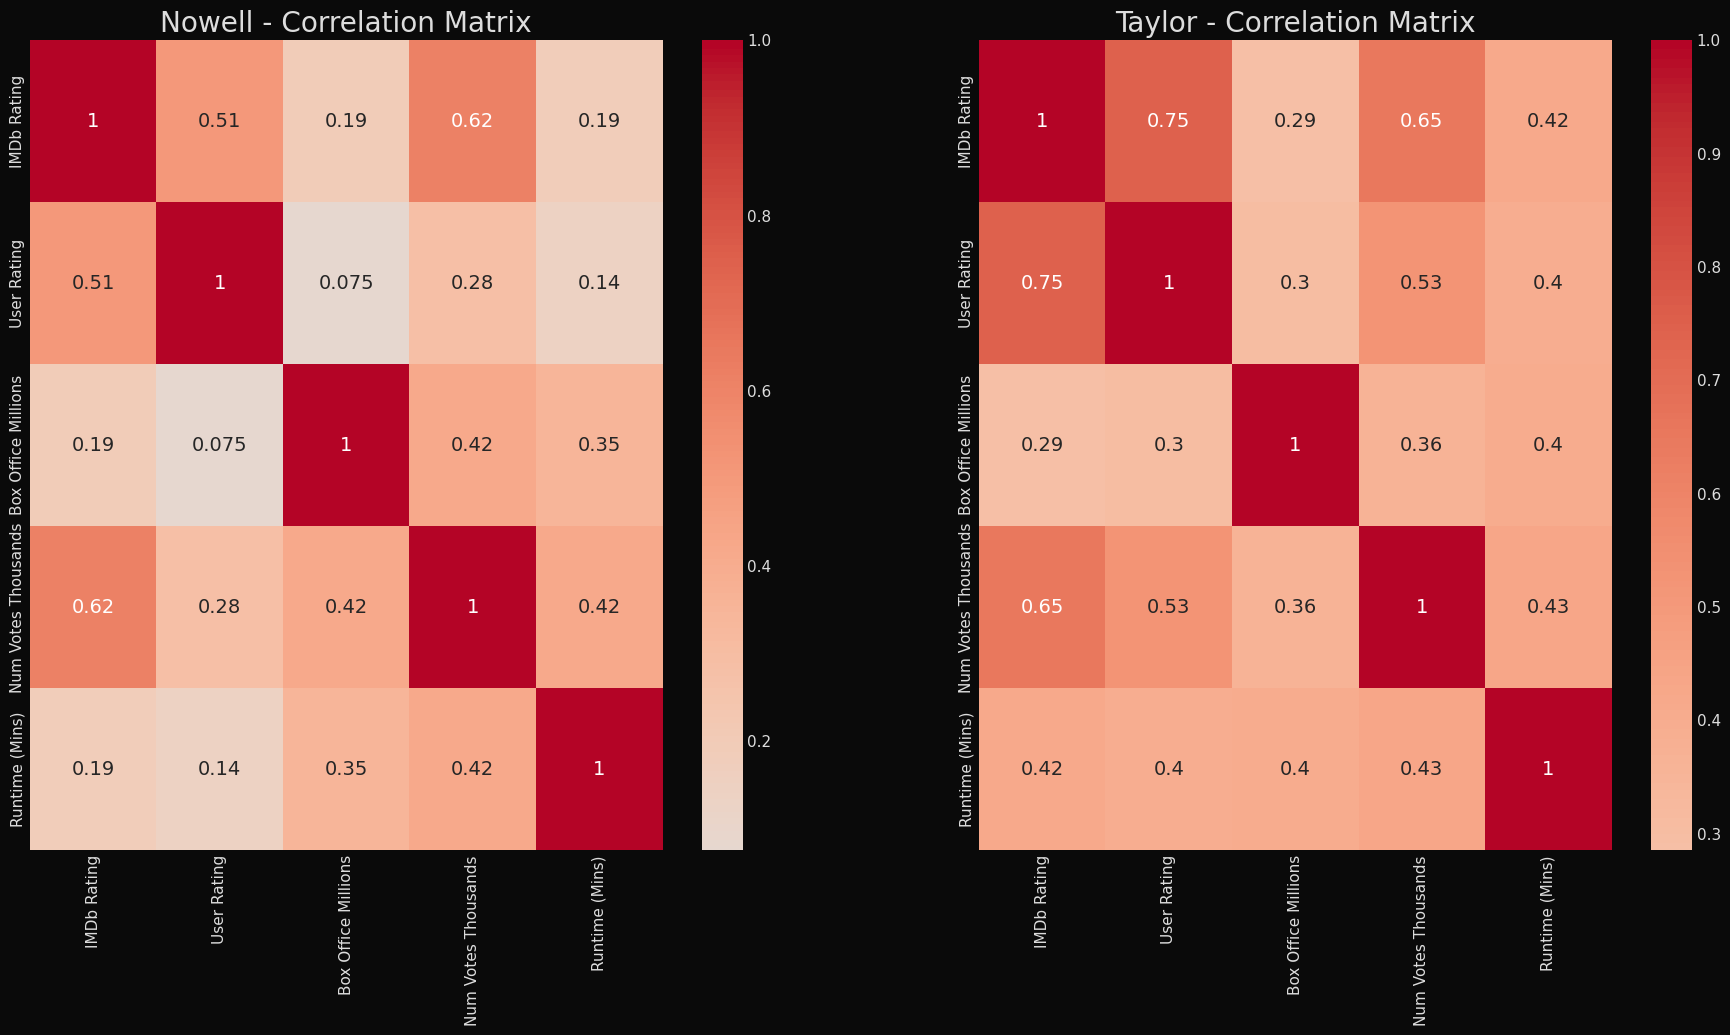

In [ ]:
corr_matrix_1 = df[nowell].iloc[:,:10].corr(numeric_only = True)
corr_matrix_2 = df[taylor].iloc[:,:10].corr(numeric_only = True)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 15))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

sns.heatmap(corr_matrix_1, annot=True, cmap='coolwarm', center=0, ax=ax1)
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax1.set_title('Nowell - Correlation Matrix')
ax2.set_title('Taylor - Correlation Matrix')
plt.show()

Seems to be less correlation for me than IMDb average. Suggests I'm not swayed by popularity. Strong corr for IMDb, weak for me. Weak correlation for both me and Taylor with IMDb rating.

### Nowell VS Taylor VS IMDb
Most loved/hated movies?


#### By Genre

Most popular genres

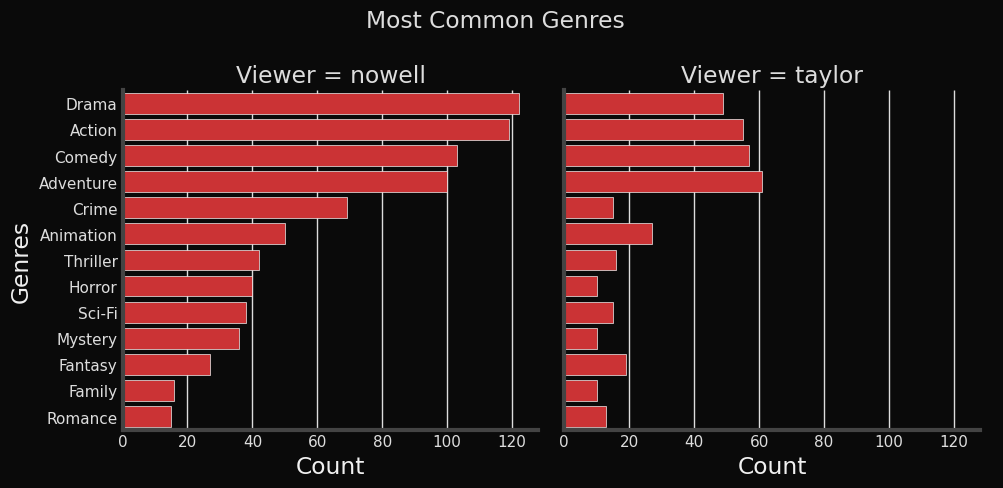

In [ ]:
min_count = 5

# Count the number of ratings per genre
genre_counts = df_genres['Genres'].value_counts()

# Filter genres with counts above the threshold
valid_genres = genre_counts[genre_counts >= min_count].index
filtered_df = df_genres[df_genres['Genres'].isin(valid_genres)]

genre_ratings = filtered_df.groupby(['Genres','Viewer']).agg({
    'User Rating':'mean',
    # 'User Rating': 'sum',
    'IMDb Rating':'mean',
    'Genres':'count'
}).rename(columns={'Genres': 'Count'}).sort_values(by =['Count','User Rating'], ascending = False)

genre_ratings.reset_index(inplace=True)

f=sns.catplot(
    data=genre_ratings,
    y='Genres', x='Count',
    kind='bar',
    col='Viewer', order = genre_ratings.sort_values(by='Count', ascending=False)['Genres'][:25],
    sharex=True
    )

# common axis labels
f.fig.suptitle('Most Common Genres')
# f.fig.supxlabel('Count')
plt.tight_layout()
plt.show()

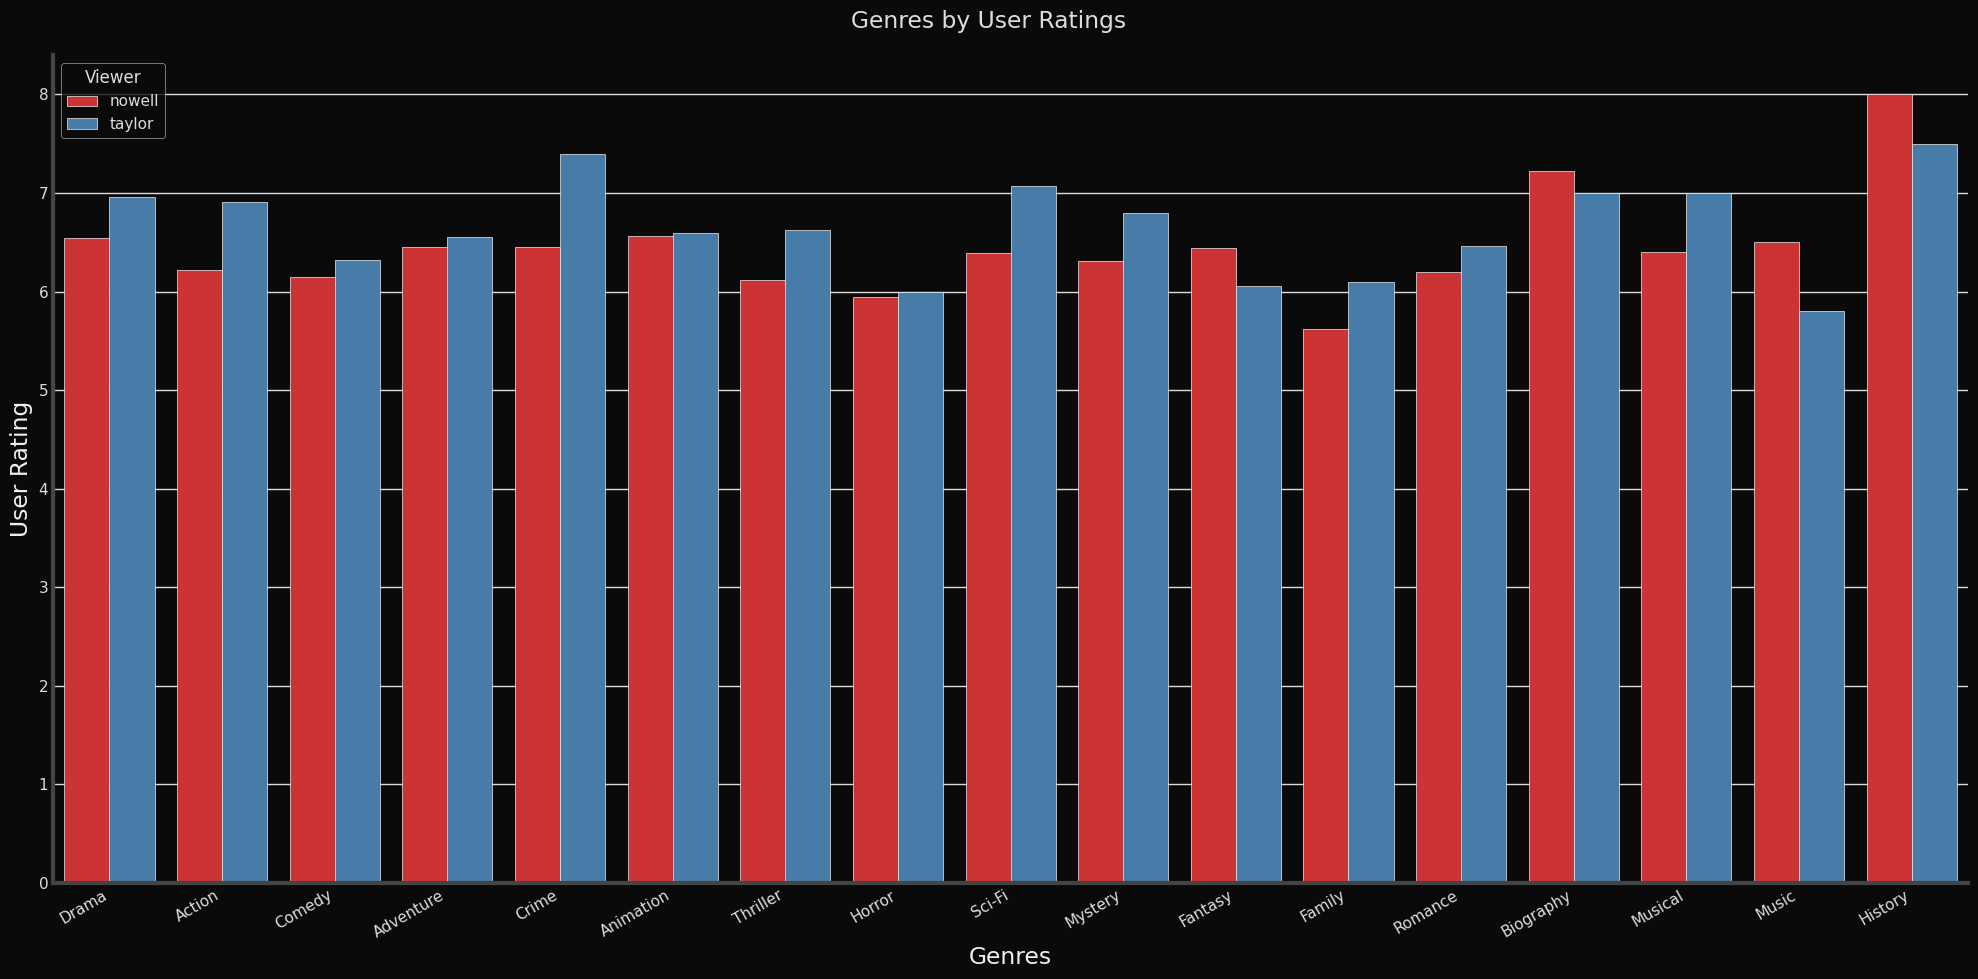

In [ ]:
fig, ax=plt.subplots(figsize=(20, 10))
g=sns.barplot(data=genre_ratings.sort_values(by='Count',ascending=False),
              x='Genres', y='User Rating',
              hue='Viewer')
fig.autofmt_xdate()
# common axis labels
fig.suptitle('Genres by User Ratings')
# g.fig.supxlabel('Genres')
plt.tight_layout()
plt.show()

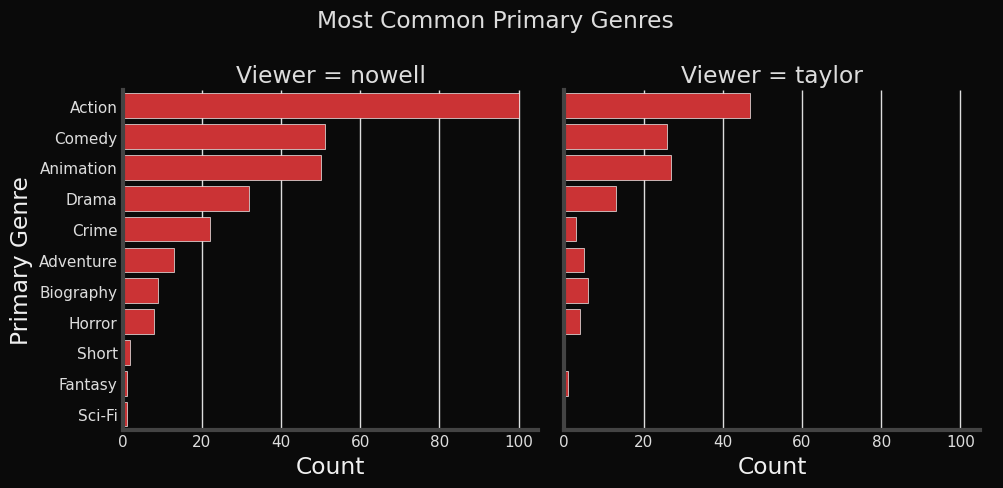

In [ ]:
primary_genre_ratings = df.groupby(['Primary Genre','Viewer']).agg({
    'User Rating':'mean',
    'IMDb Rating':'mean',
    'Primary Genre':'count'
}).rename(columns={'Primary Genre': 'Count'}).sort_values(by =['Count','User Rating'], ascending = False)

primary_genre_ratings.reset_index(inplace=True)
primary_genre_ratings

g=sns.catplot(data =primary_genre_ratings,
            col='Viewer', kind='bar',
            y='Primary Genre', x='Count',
            order = primary_genre_ratings.sort_values(by='Count', ascending=False)['Primary Genre'][:20])

# common axis labels
g.fig.suptitle('Most Common Primary Genres')
# g.fig.supxlabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
genre_ratings_1=genre_ratings.loc[genre_ratings['Viewer']=='nowell']
genre_ratings_2=genre_ratings.loc[genre_ratings['Viewer']=='taylor']

top_genres_1=zip(genre_ratings_1['Count'][:4],genre_ratings_1['Genres'][:4])
top_genres_1 = dict(top_genres_1)
top_genres_2 =zip(genre_ratings_1['Count'][:4],genre_ratings_1['Genres'][:4])
top_genres_1 = dict(top_genres_1)

uncommon_genres_1=zip(genre_ratings_1['Count'][4:],genre_ratings_1['Genres'][4:])
uncommon_genres_1 = dict(uncommon_genres_1)

uncommon_genres_2=zip(genre_ratings_2['Count'][4:],genre_ratings_2['Genres'][4:])
uncommon_genres_2 = dict(uncommon_genres_2)

print('Nowell Top Genres:', top_genres_1)
print('Taylor Top Genres:', top_genres_2)

print('Nowell Uncommon Genres:', uncommon_genres_1)
print('Taylor Uncommon Genres:', uncommon_genres_2)

Nowell Top Genres: {122: 'Drama', 119: 'Action', 103: 'Comedy', 100: 'Adventure'}
Taylor Top Genres: <zip object at 0x7fa511b08dc0>
Nowell Uncommon Genres: {69: 'Crime', 50: 'Animation', 42: 'Thriller', 40: 'Horror', 38: 'Sci-Fi', 36: 'Mystery', 27: 'Fantasy', 16: 'Family', 15: 'Romance', 9: 'Biography', 5: 'Musical', 4: 'Music', 3: 'History'}
Taylor Uncommon Genres: {27: 'Animation', 19: 'Fantasy', 16: 'Thriller', 15: 'Sci-Fi', 13: 'Romance', 10: 'Horror', 6: 'Biography', 5: 'Music', 4: 'Musical', 2: 'History'}


Our graphs are very similar suggesting a similar taste in genres. Almost perfect correlation of genres. Perhaps there's a confounding variable like the genres action, drama and adventure being vague enough to apply to any film.

In [ ]:
## Calculate correlation between me and Taylor

#### By Actor & Director

Text(0.5, 0.98, 'Most Common Actors')

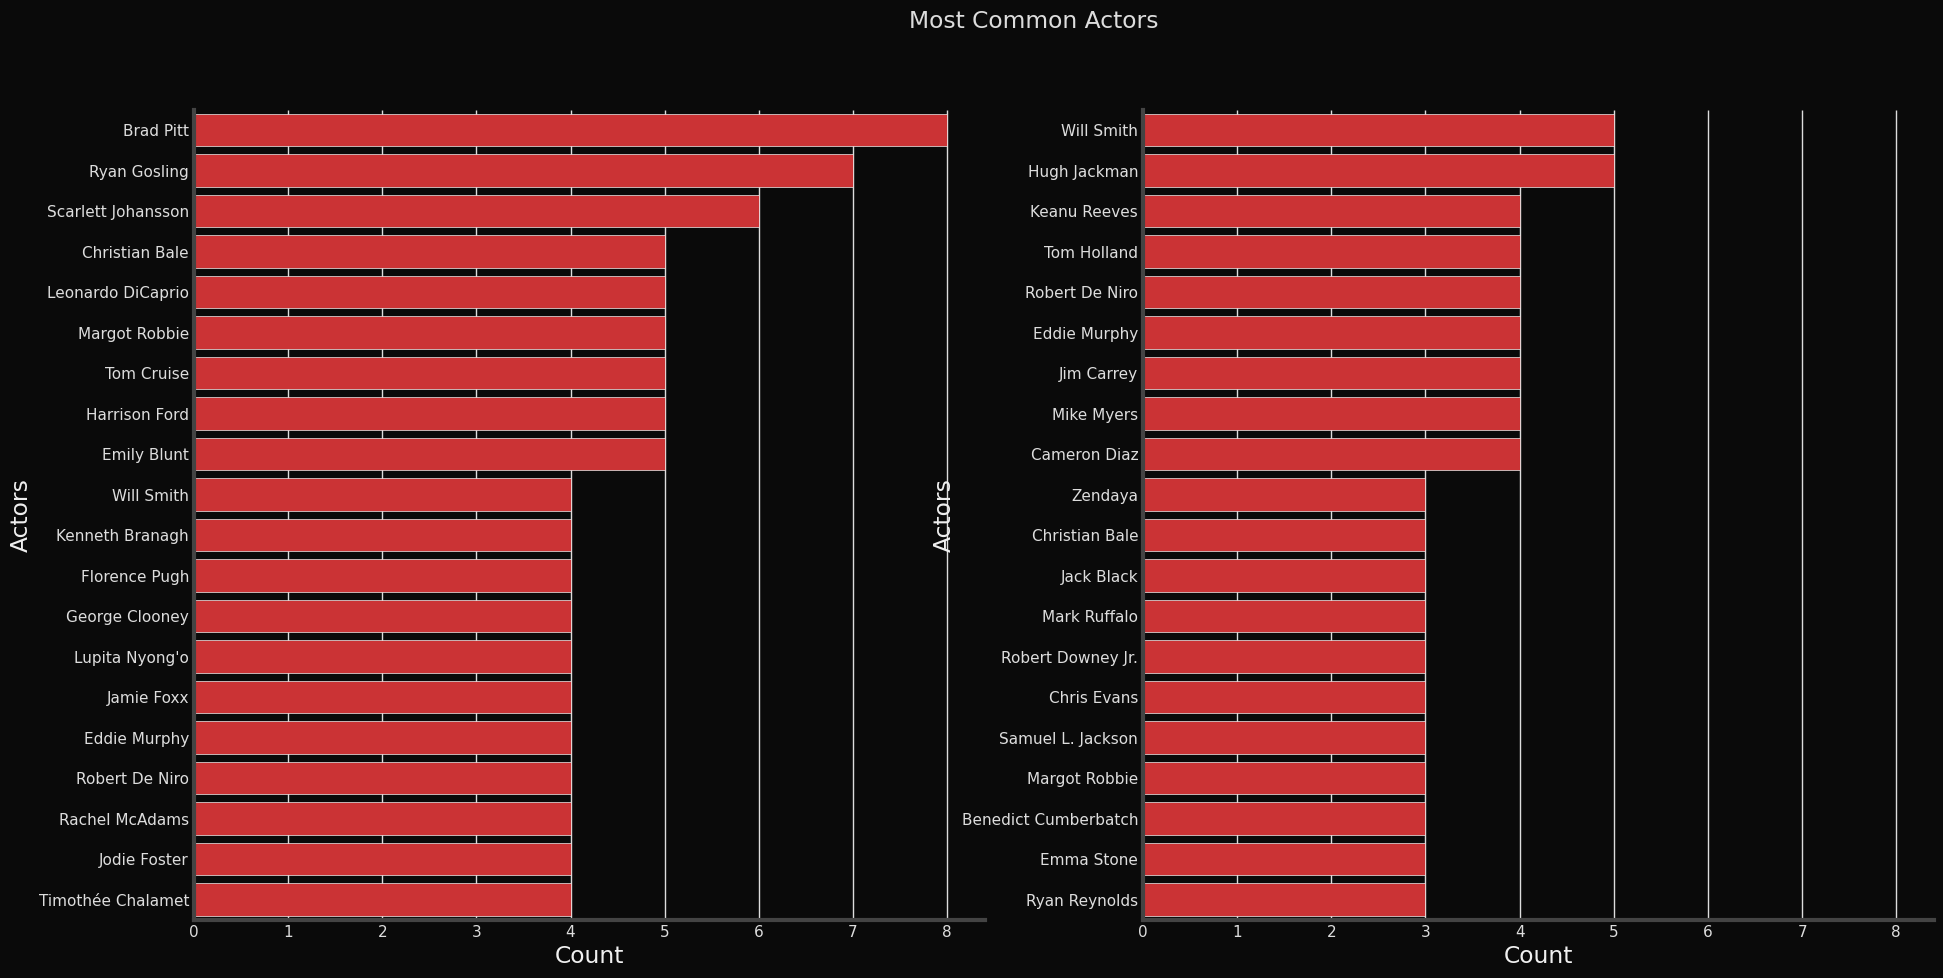

In [ ]:
actor_summary = df_actors.groupby(['Actors','Viewer']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Actors': 'count'
}).rename(columns={'Actors': 'Count'}).sort_values(by=['Count', 'User Rating'], ascending=False)

actor_summary.reset_index(inplace=True)

actor_summary_1 = actor_summary.loc[actor_summary['Viewer']=='nowell']
actor_summary_2 = actor_summary.loc[actor_summary['Viewer']=='taylor']

fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10), sharex=True)
f=sns.barplot(data=actor_summary_1,
              y='Actors', x='Count',
              ax=ax1,
              order = actor_summary_1.sort_values(by='Count', ascending=False)['Actors'][:20],
              )
g=sns.barplot(data=actor_summary_2,
              y='Actors', x='Count',
              ax=ax2,
              order = actor_summary_2.sort_values(by='Count', ascending=False)['Actors'][:20])
ax2.set_ylabel=None
fig.suptitle('Most Common Actors')

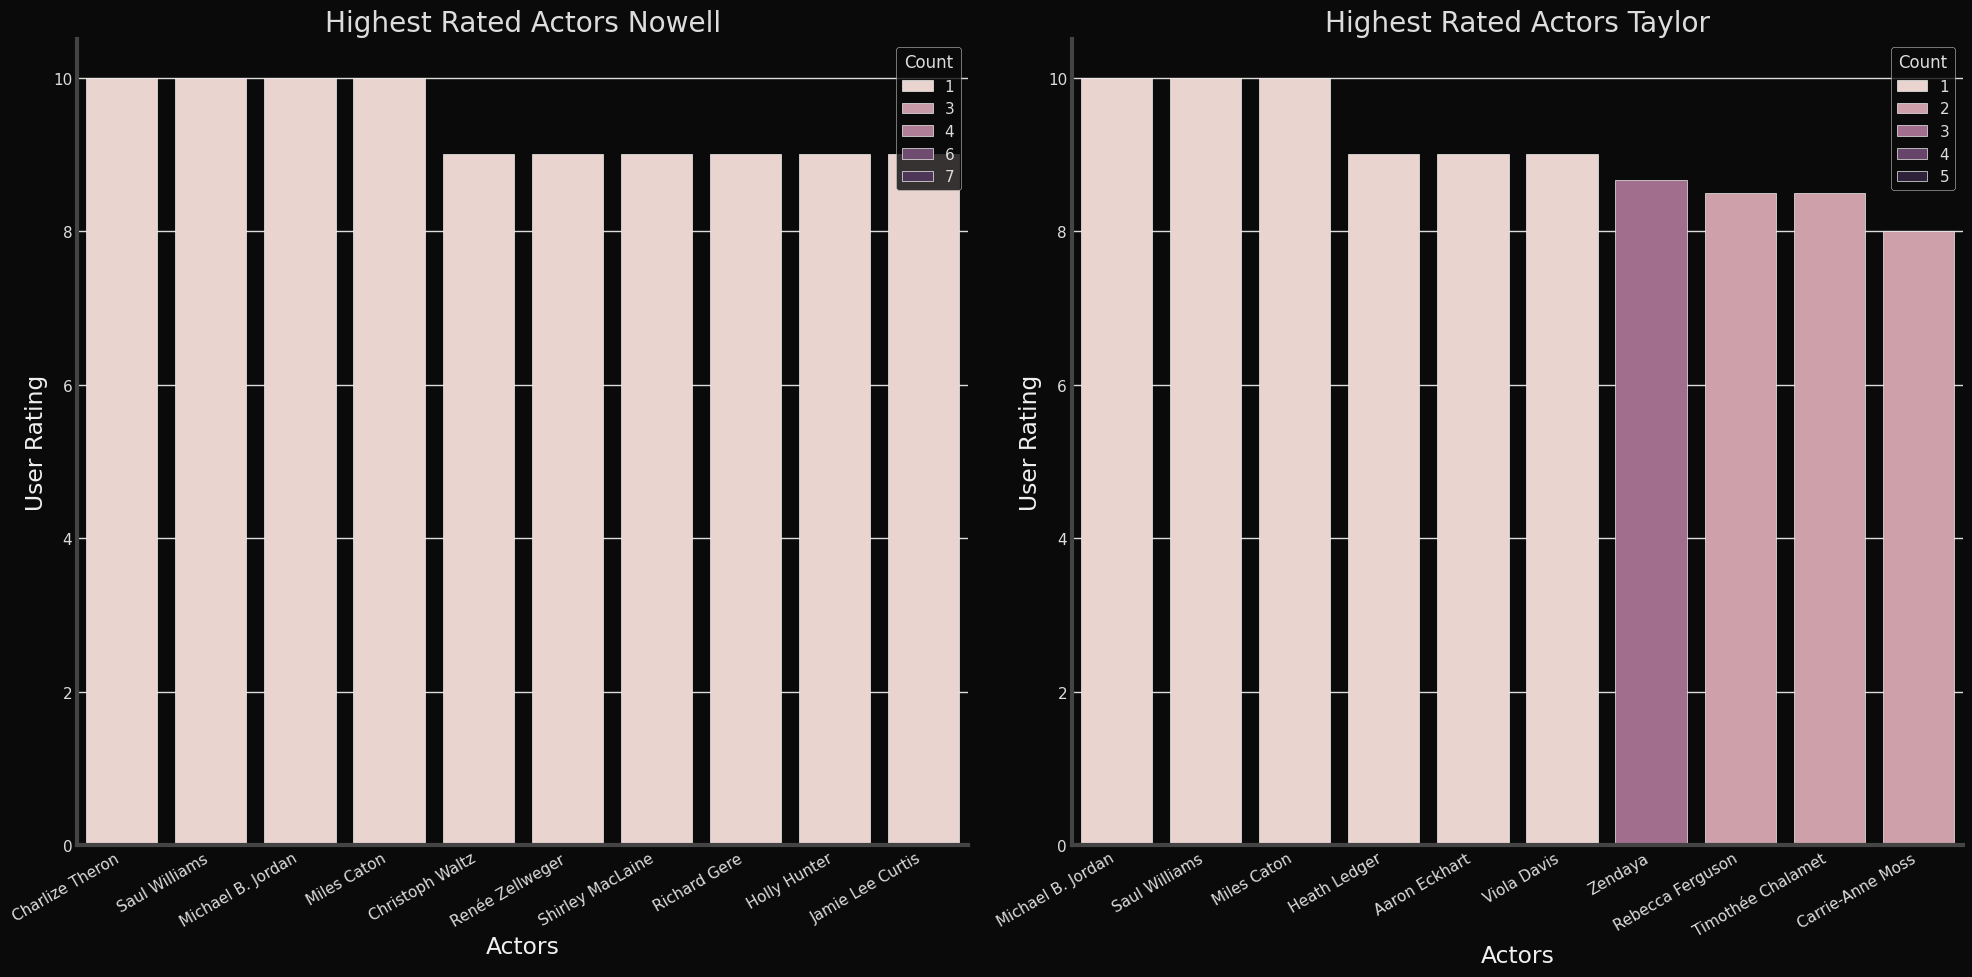

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10))
g=sns.barplot(data=actor_summary_1,
              x='Actors', y='User Rating',
              ax=ax1,
              hue='Count',
              order = actor_summary_1.sort_values(by='User Rating', ascending=False)['Actors'][:10])
f=sns.barplot(data=actor_summary_2,
              x='Actors', y='User Rating',
              ax=ax2,
              hue='Count',
              order = actor_summary_2.sort_values(by='User Rating', ascending=False)['Actors'][:10])
fig.autofmt_xdate()
ax1.set_title('Highest Rated Actors Nowell')
ax2.set_title('Highest Rated Actors Taylor')
plt.tight_layout()
plt.show()

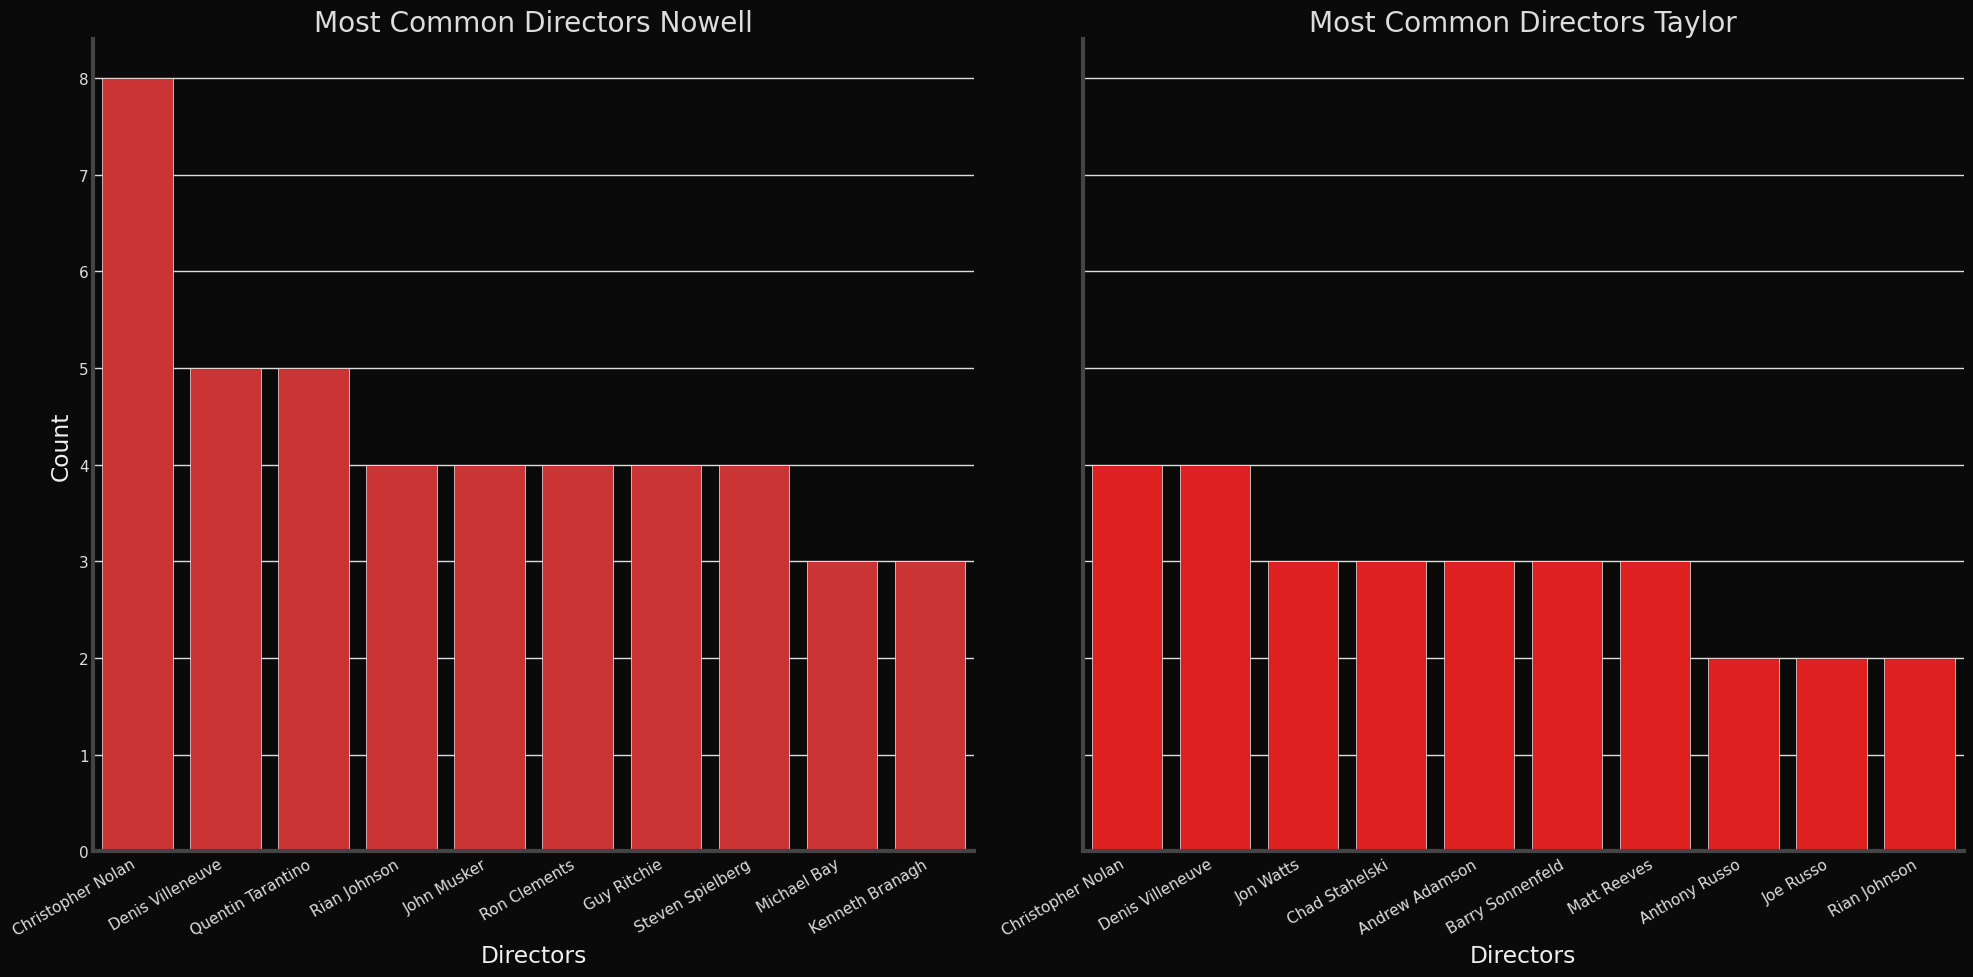

In [ ]:
director_summary = df_directors.groupby(['Directors','Viewer']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Directors': 'count'
}).rename(columns={'Directors': 'Count'}).sort_values(by=['Count', 'User Rating'], ascending=False)

director_summary.reset_index(inplace=True)

director_summary_1 = director_summary.loc[director_summary['Viewer']=='nowell']
director_summary_2 = director_summary.loc[director_summary['Viewer']=='taylor']

# Plots
fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10), sharey=True)
g=sns.barplot(data=director_summary_1,
              x='Directors', y='Count',
              ax=ax1,
              order = director_summary_1.sort_values(by='Count', ascending=False)['Directors'][:10])
f=sns.barplot(data=director_summary_2,
              x='Directors', y='Count',
              color = 'red', ax=ax2,
              order = director_summary_2.sort_values(by='Count', ascending=False)['Directors'][:10])
fig.autofmt_xdate()
ax1.set_title('Most Common Directors Nowell')
ax2.set_title('Most Common Directors Taylor')
plt.tight_layout()
plt.show()

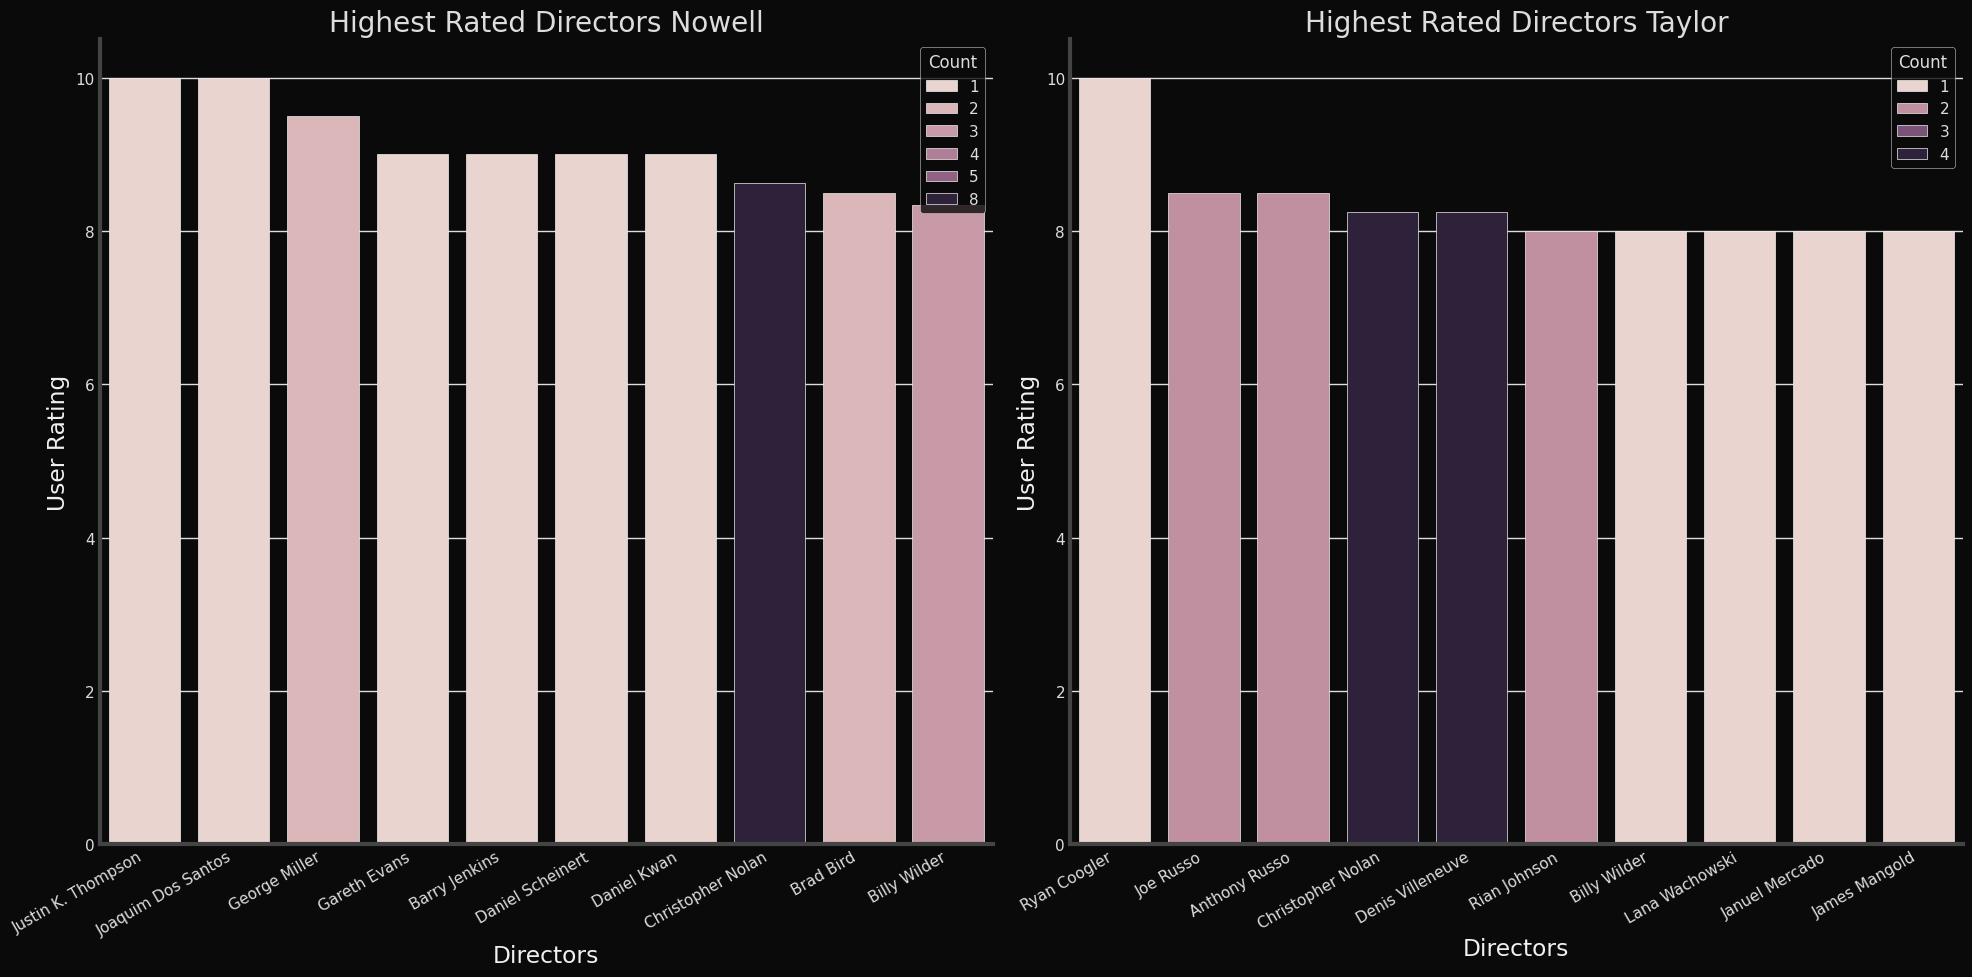

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10))
g=sns.barplot(data=director_summary_1,
              x='Directors', y='User Rating',
              ax=ax1,
              hue='Count',
              order = director_summary_1.sort_values(by='User Rating', ascending=False)['Directors'][:10])
f=sns.barplot(data=director_summary_2,
              x='Directors', y='User Rating',
              ax=ax2,
              hue='Count',
              order = director_summary_2.sort_values(by='User Rating', ascending=False)['Directors'][:10])
fig.autofmt_xdate()
ax1.set_title('Highest Rated Directors Nowell')
ax2.set_title('Highest Rated Directors Taylor')
plt.tight_layout()
plt.show()

#### By Year

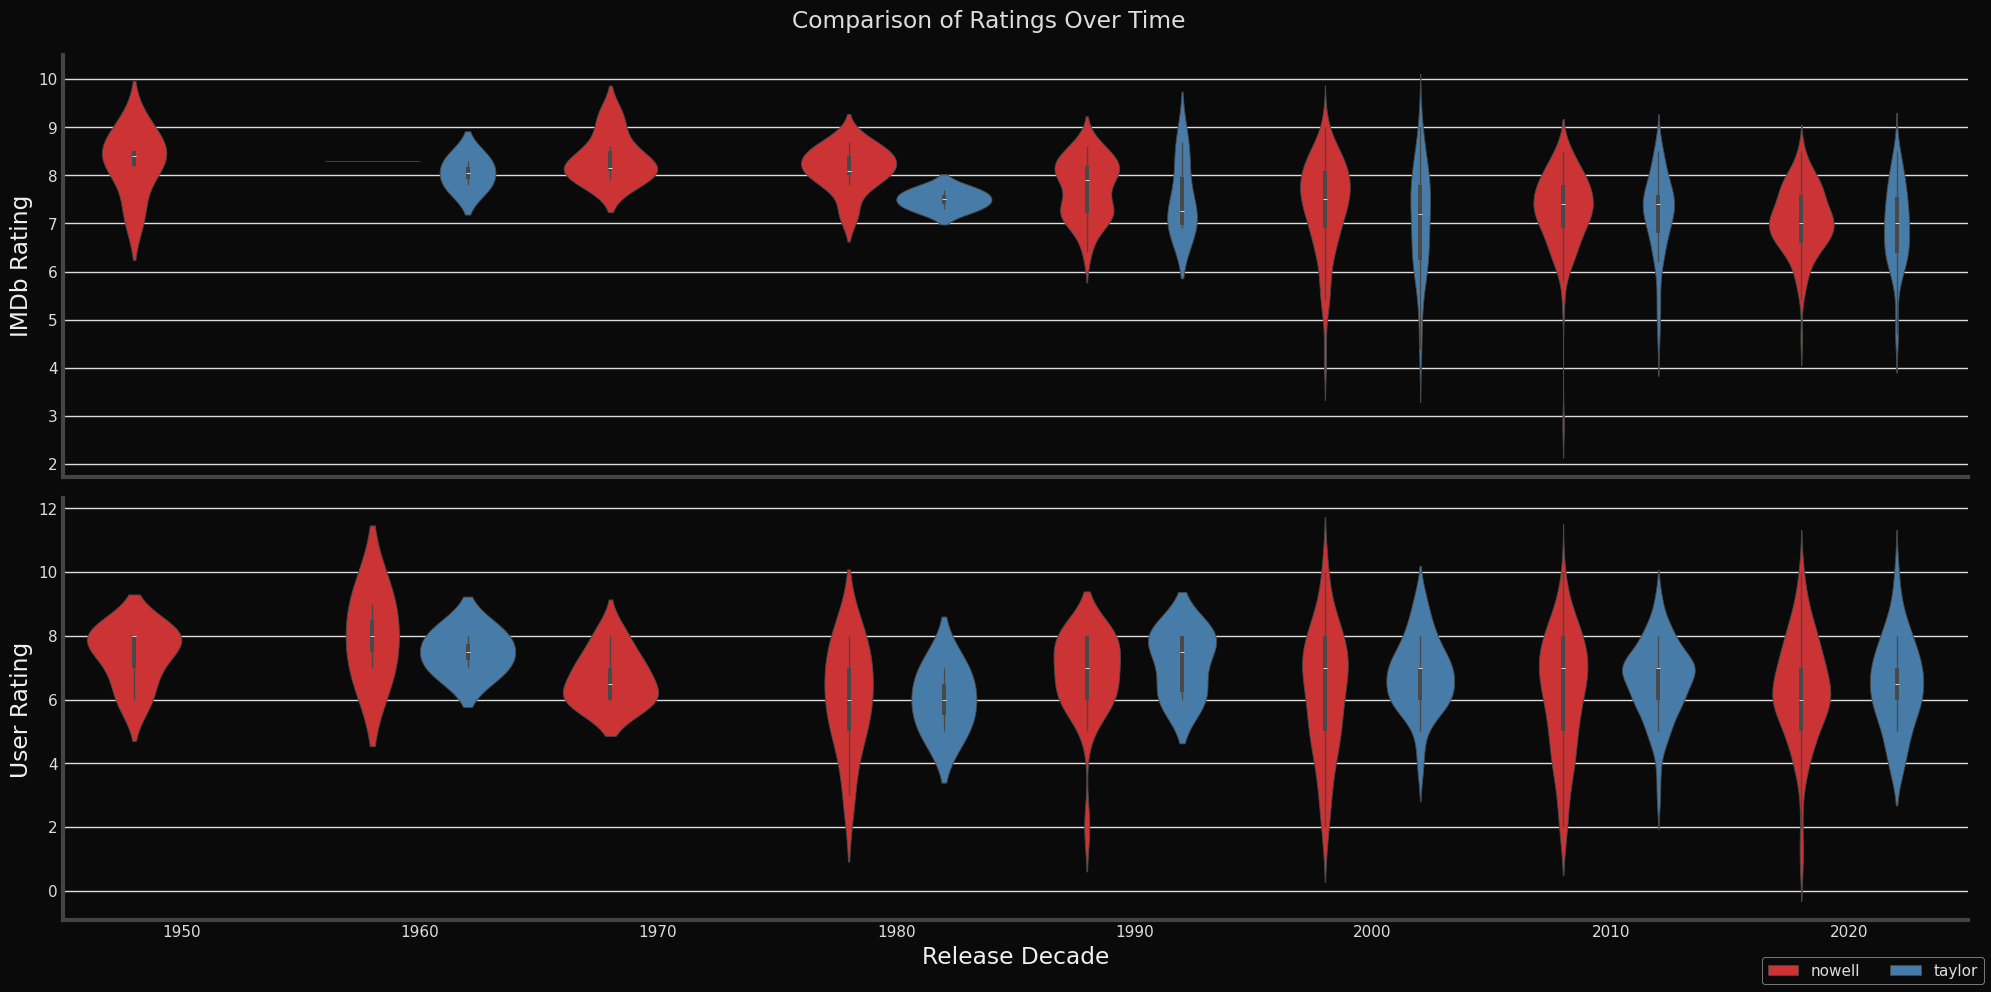

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 10), sharex=True)

sns.violinplot(x='Release Decade', y='IMDb Rating', data=df, hue='Viewer', ax=axes[0])
sns.violinplot(x='Release Decade', y='User Rating', data=df, hue='Viewer', ax=axes[1], legend=False)
axes[0].legend_.remove()

fig.suptitle("Comparison of Ratings Over Time")
fig.legend(loc='lower right', ncols=2)
plt.tight_layout()

In [ ]:
px.box(data_frame=df, y='IMDb Rating Rounded', x='Year Rated',
title = 'Rounded IMDb Ratings over time',
facet_col = 'Viewer',
hover_data={
        'Title': True,
        'User Rating': ':.2f',
        'IMDb Rating': ':.2f',
    } )

/tmp/ipython-input-826488046.py:5: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



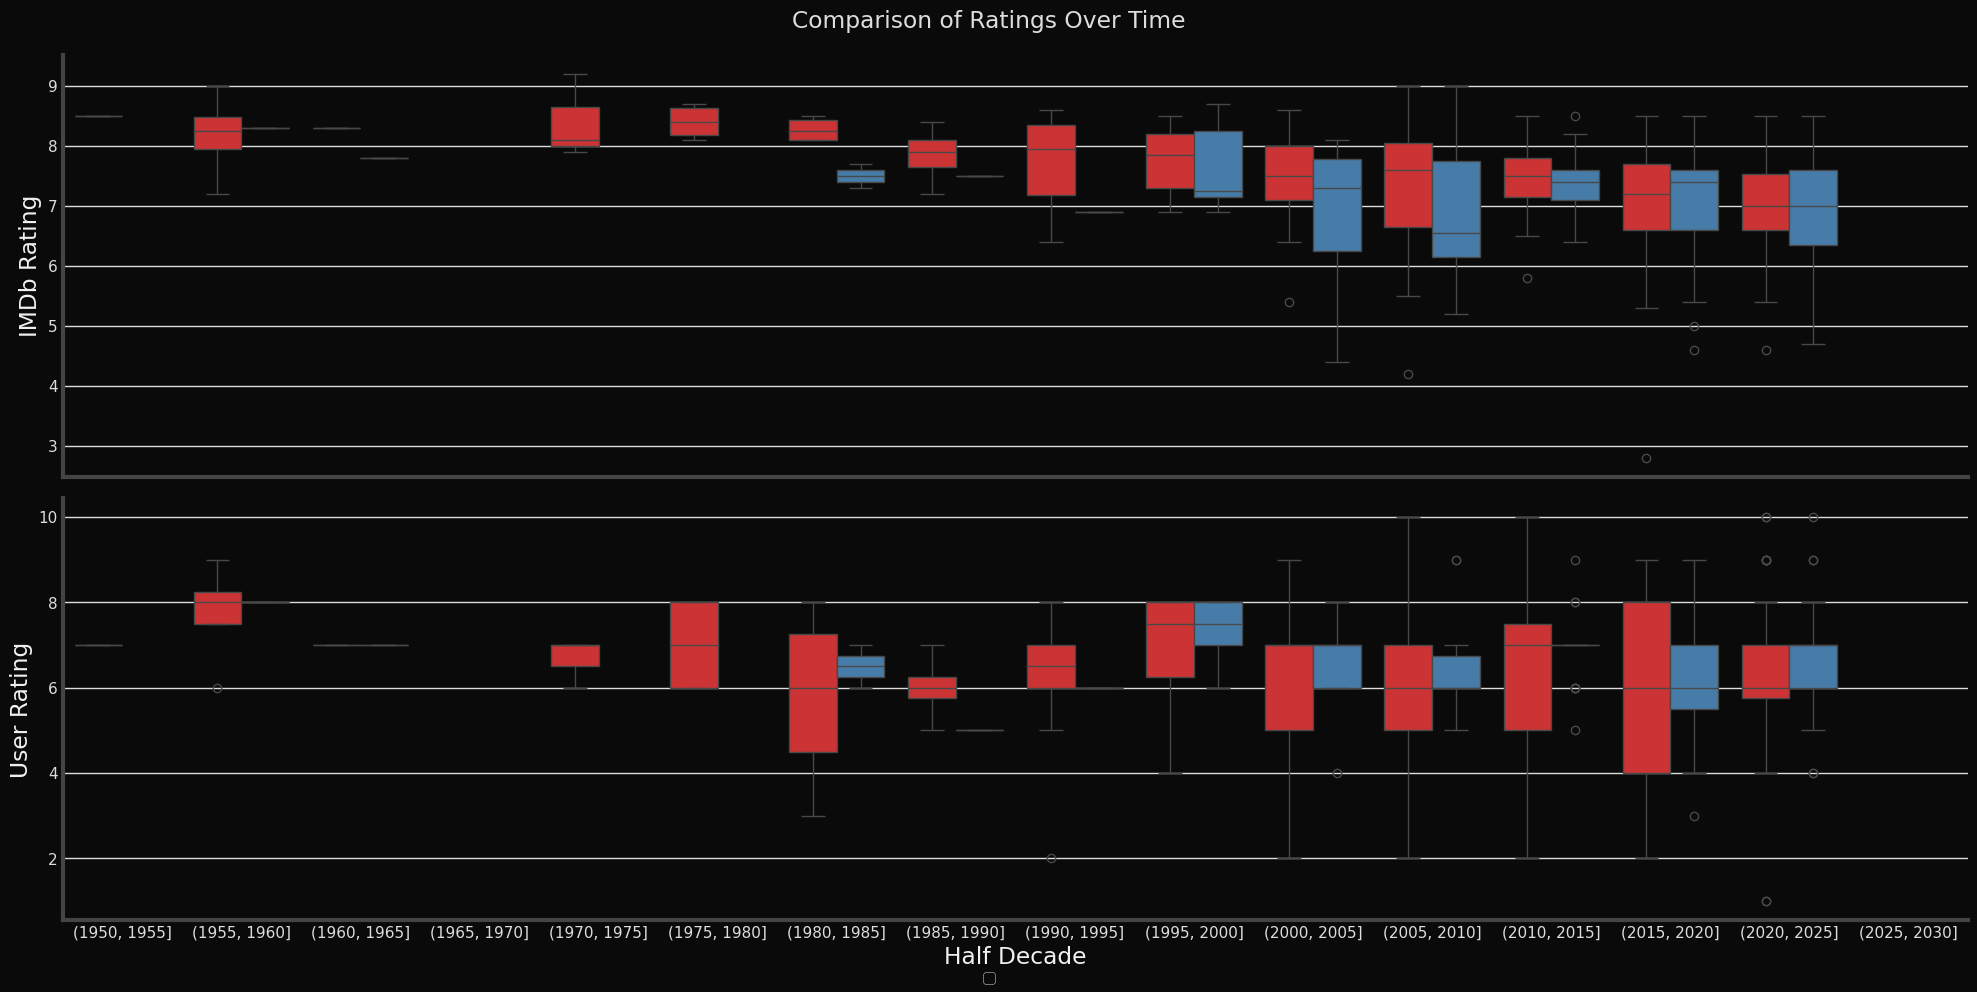

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 10), sharex=True)

sns.boxplot(x='Half Decade', y='IMDb Rating', data=df, hue='Viewer', legend=False, ax=axes[0])
sns.boxplot(x='Half Decade', y='User Rating', data=df, hue='Viewer', legend=False, ax=axes[1])
fig.legend(loc='lower center')
fig.suptitle("Comparison of Ratings Over Time")
plt.tight_layout()
plt.show()

In [ ]:
## Break down habits year by year
df['Year Rated'].value_counts()
display(df.groupby(['Year Rated','Viewer'])[['User Rating', 'IMDb Rating']].describe())

year_sum_1 = df[nowell].groupby('Year Rated').agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Year Rated': 'count'
}).rename(columns={'Year Rated': 'Count'}
          ).sort_values(by=['Year Rated', 'User Rating'], ascending=False
                                                       )

display(year_sum_1.head(10))
correlation = year_sum_1['User Rating'].corr(year_sum_1['IMDb Rating'])
print(f"Correlation between Nowell's rating and IMDb rating: {correlation:.2f}")

User Rating                                     IMDb Rating  \
                        count mean  std  min  25%  50%  75%   max       count   
Year Rated Viewer                                                               
2020       nowell        9.00 5.33 1.41 4.00 4.00 5.00 6.00  8.00        9.00   
2021       nowell       54.00 5.50 1.48 2.00 5.00 6.00 7.00  8.00       54.00   
           taylor       42.00 6.69 1.44 3.00 6.00 7.00 8.00  9.00       42.00   
2022       nowell       18.00 5.72 1.32 3.00 5.00 6.00 6.75  8.00       18.00   
           taylor       32.00 6.19 1.06 4.00 6.00 6.00 7.00  8.00       32.00   
2023       nowell       20.00 6.05 1.36 2.00 5.00 6.00 7.00  8.00       20.00   
           taylor       15.00 7.07 0.70 6.00 7.00 7.00 7.50  8.00       15.00   
2024       nowell      157.00 6.76 1.80 1.00 6.00 7.00 8.00 10.00      157.00   
           taylor       30.00 6.67 1.03 4.00 6.00 7.00 7.00  8.00       30.00   
2025       nowell       32.00 6.47 1.50 3.00 6.00 7.00 7.00 10.00       32.00   
           taylor       14.00 6.93 1.59 4.00 6.25 7.00 7.75 10.00       14.00   

                                                      
                  mean  std  min  25%  50%  75%  max  
Year Rated Viewer                                     
2020       nowell 7.53 0.78 6.30 6.90 8.00 8.10 8.20  
2021       nowell 7.02 0.82 4.20 6.62 7.10 7.50 8.20  
           taylor 7.12 1.04 4.60 6.30 7.20 8.07 9.00  
2022       nowell 7.06 0.54 6.30 6.60 6.95 7.60 7.90  
           taylor 6.81 0.86 4.40 6.38 6.90 7.30 8.30  
2023       nowell 7.06 0.76 5.70 6.57 7.20 7.60 8.30  
           taylor 7.43 0.41 6.30 7.30 7.50 7.65 8.00  
2024       nowell 7.47 0.88 2.80 6.90 7.50 8.10 9.20  
           taylor 7.23 0.92 4.70 6.83 7.45 7.88 8.40  
2025       nowell 7.45 0.50 6.50 7.15 7.40 7.72 8.50  
           taylor 7.31 0.60 5.90 7.05 7.40 7.47 8.50

,User Rating,IMDb Rating,Count
Year Rated,,,
2025,6.47,7.45,32
2024,6.76,7.47,157
2023,6.05,7.05,20
2022,5.72,7.06,18
2021,5.50,7.02,54
2020,5.33,7.53,9


Correlation between Nowell's rating and IMDb rating: 0.34


I'm seemingly getting more positive as time passes.

In [ ]:
year_sum_2 = df[taylor].groupby('Year Rated').agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Year Rated': 'count'
}).rename(columns={'Year Rated': 'Count'}).sort_values(by=['Year Rated', 'User Rating'], ascending=False)

display(year_sum_2.head(10))
correlation = year_sum_2['User Rating'].corr(year_sum_2['IMDb Rating'])
print(f"Correlation between Taylor's rating and IMDb rating: {correlation:.2f}")

,User Rating,IMDb Rating,Count
Year Rated,,,
2025,6.93,7.31,14
2024,6.67,7.23,30
2023,7.07,7.43,15
2022,6.19,6.81,32
2021,6.69,7.12,42


Correlation between Taylor's rating and IMDb rating: 0.98


Taylor seems quite consistent with his ratings

When did we start tracking?

In [ ]:
min_date_1 = df[nowell]['Date Rated'].min()
min_date_2 = df[taylor]['Date Rated'].min()

print(f"Nowell started tracking on {min_date_1.date()} by watching {df[nowell].loc[df[nowell]['Date Rated'] == min_date_1, 'Title'].iloc[0]}")
print(f"Taylor started tracking on {min_date_2.date()} by watching {df[taylor].loc[df[taylor]['Date Rated'] == min_date_2, 'Title'].iloc[0]}")

Nowell started tracking on 2020-12-16 by watching Howl's Moving Castle
Taylor started tracking on 2021-04-04 by watching Django Unchained


##### Time Series

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:2761: UserWarning:

catplot is a figure-level function and does not accept target axes. You may wish to try stripplot



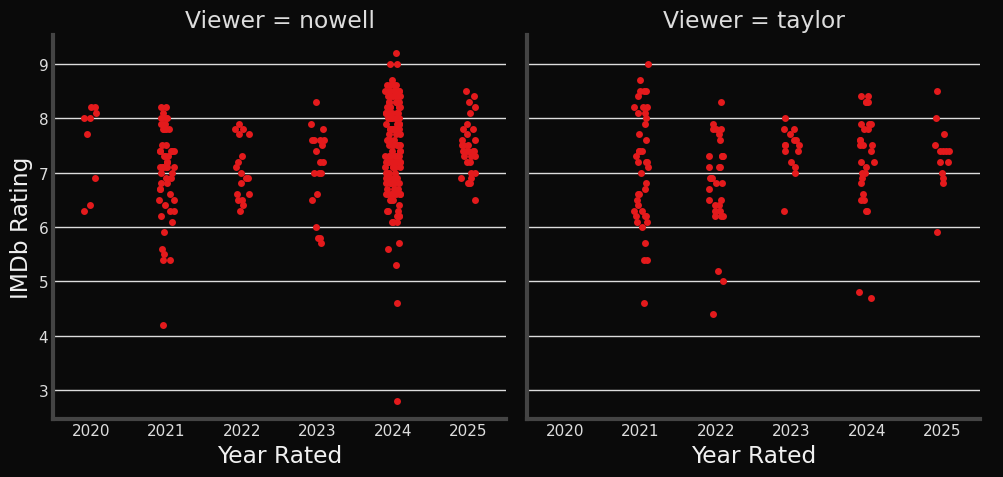

In [ ]:
sns.catplot(
    data=df, x='Year Rated', y='IMDb Rating',
    col='Viewer', kind='strip',
    sharey=True, ax=ax1)
fig.suptitle('IMDb Rating Over Time')
fig.supxlabel('Year Rated')
plt.tight_layout()
plt.show()

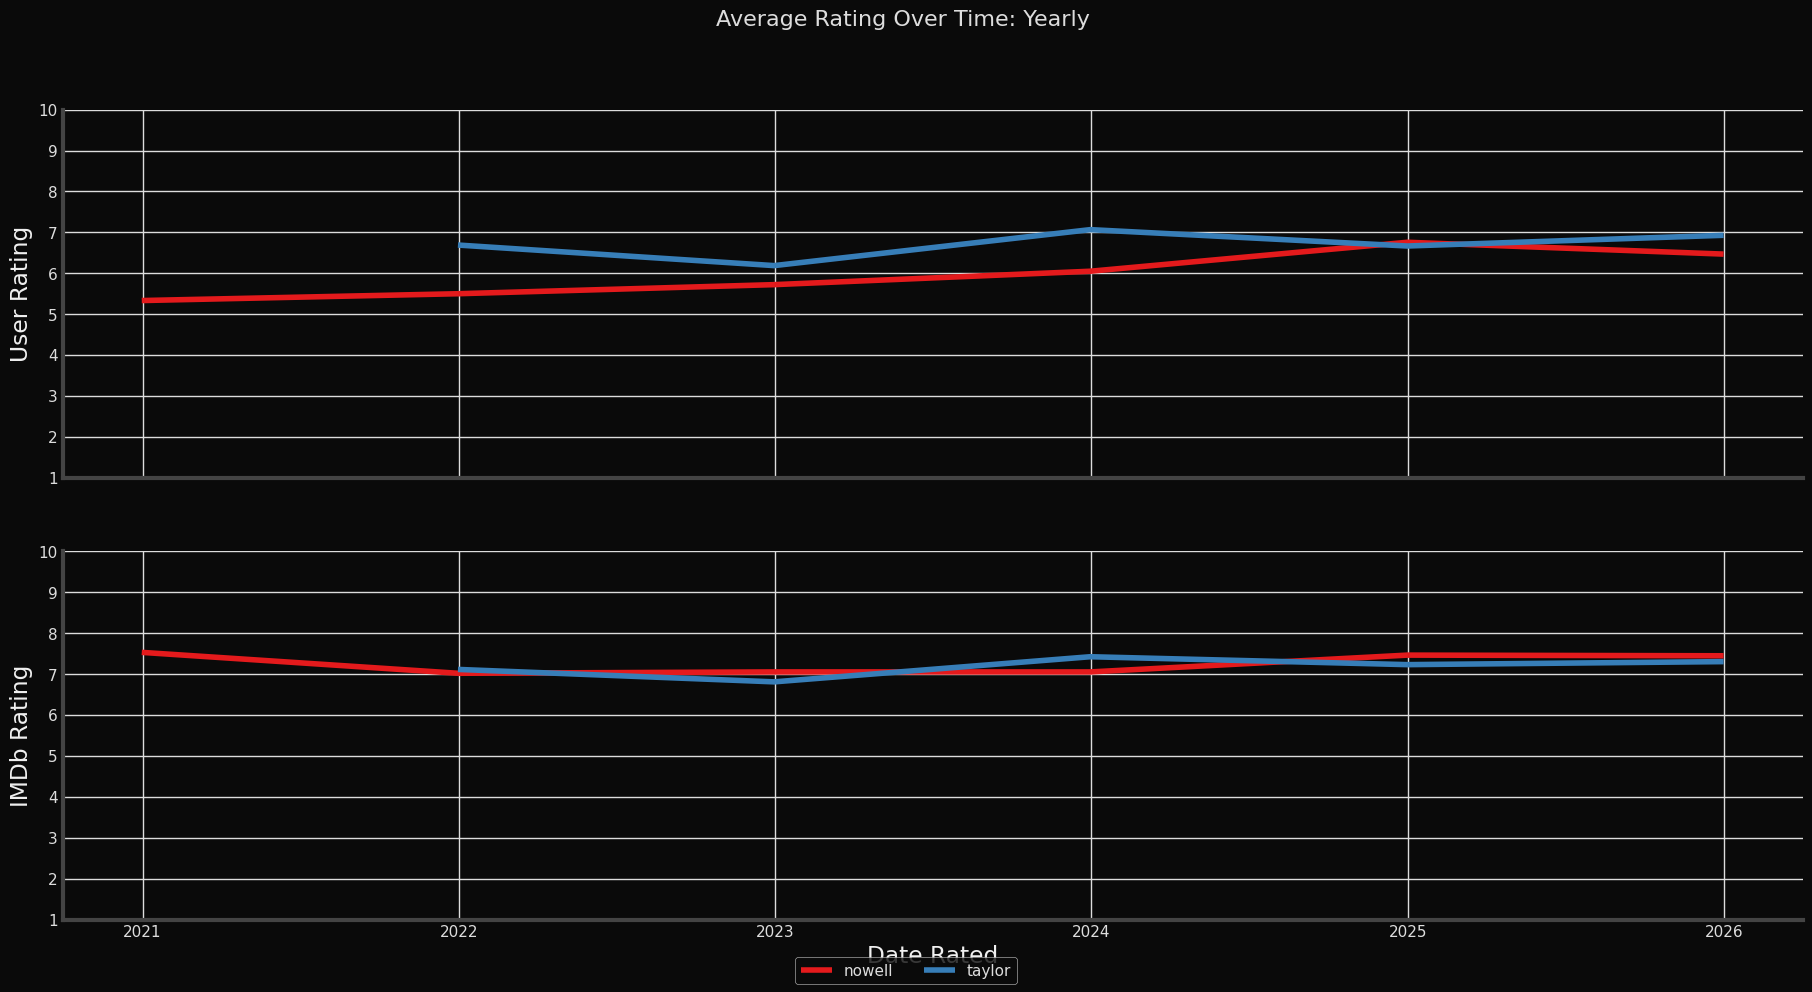

In [ ]:
yearly  = df.groupby(['Viewer', pd.Grouper(key='Date Rated', freq='YE')]
                     )[['User Rating', 'IMDb Rating']].mean().reset_index()

fig, (ax1, ax2)=plt.subplots(2,1, figsize=(20, 10), sharex=True)
g=sns.lineplot(yearly,x='Date Rated', y='User Rating', hue='Viewer', ax=ax1, legend=False)
f=sns.lineplot(yearly,x='Date Rated', y='IMDb Rating', hue='Viewer', ax=ax2).legend_.remove()
ax1.set_ylim(1,10)
ax2.set_ylim(ax1.get_ylim())
fig.suptitle('Average Rating Over Time: Yearly', fontsize=16)
fig.legend(loc='lower center', ncols=2)
plt.show()

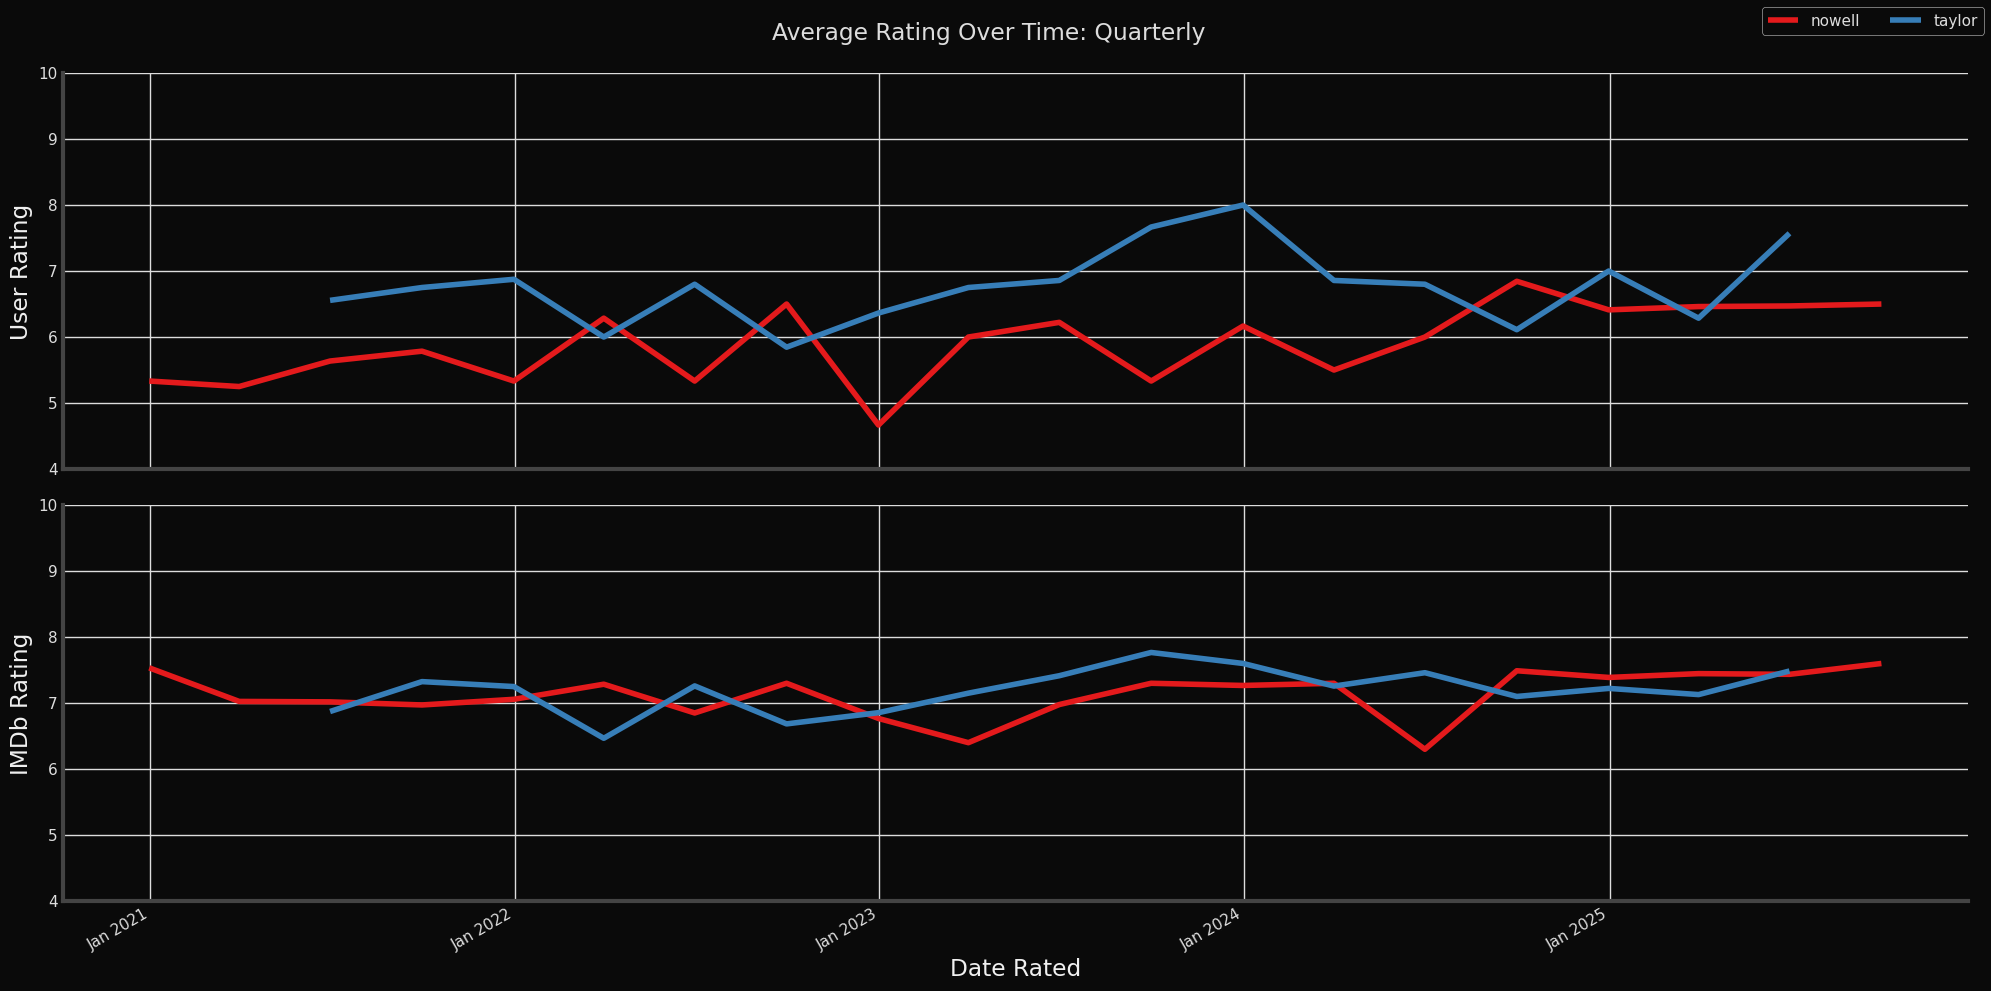

In [ ]:
quarterly = (
    df.groupby(['Viewer',pd.Grouper(key='Date Rated', freq='QE')])
    [['User Rating', 'IMDb Rating']].mean()
    .reset_index()
)

fig, (ax1, ax2)=plt.subplots(2,1, figsize=(20, 10), sharex=True)
g=sns.lineplot(quarterly,x='Date Rated', y='User Rating',
               hue='Viewer', ax=ax1,
               legend=False)
f=sns.lineplot(quarterly,x='Date Rated', y='IMDb Rating',
               hue='Viewer', ax=ax2,
               )
mpl_dates.MonthLocator(bymonth=[1,4,7,10])
ax2.xaxis.set_major_formatter(mpl_dates.DateFormatter('%b %Y'))
ax2.legend_.remove()
ax1.set_ylim(4,10)
ax2.set_ylim(ax1.get_ylim())
fig.autofmt_xdate()
fig.suptitle('Average Rating Over Time: Quarterly')
fig.legend(ncols=2)
plt.tight_layout()
plt.show()

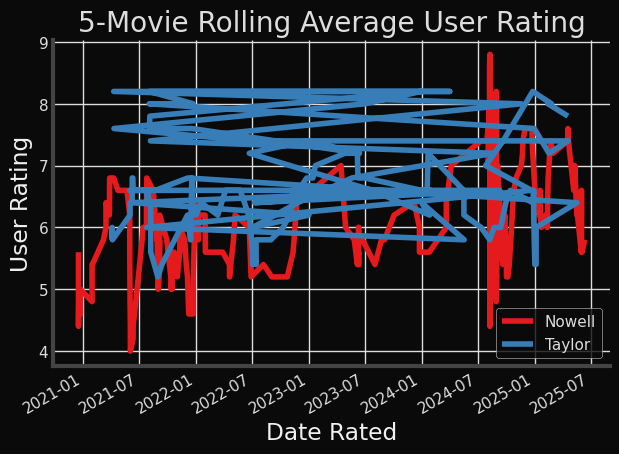

In [ ]:
df[nowell].set_index('Date Rated')['User Rating'].rolling(window=5).mean().plot(
    title='5-Movie Rolling Average Rating',
    label='Nowell')
df[taylor].set_index('Date Rated')['User Rating'].rolling(window=5).mean().plot(
    title='5-Movie Rolling Average User Rating',
    label='Taylor',
    ylabel='User Rating')
plt.legend()

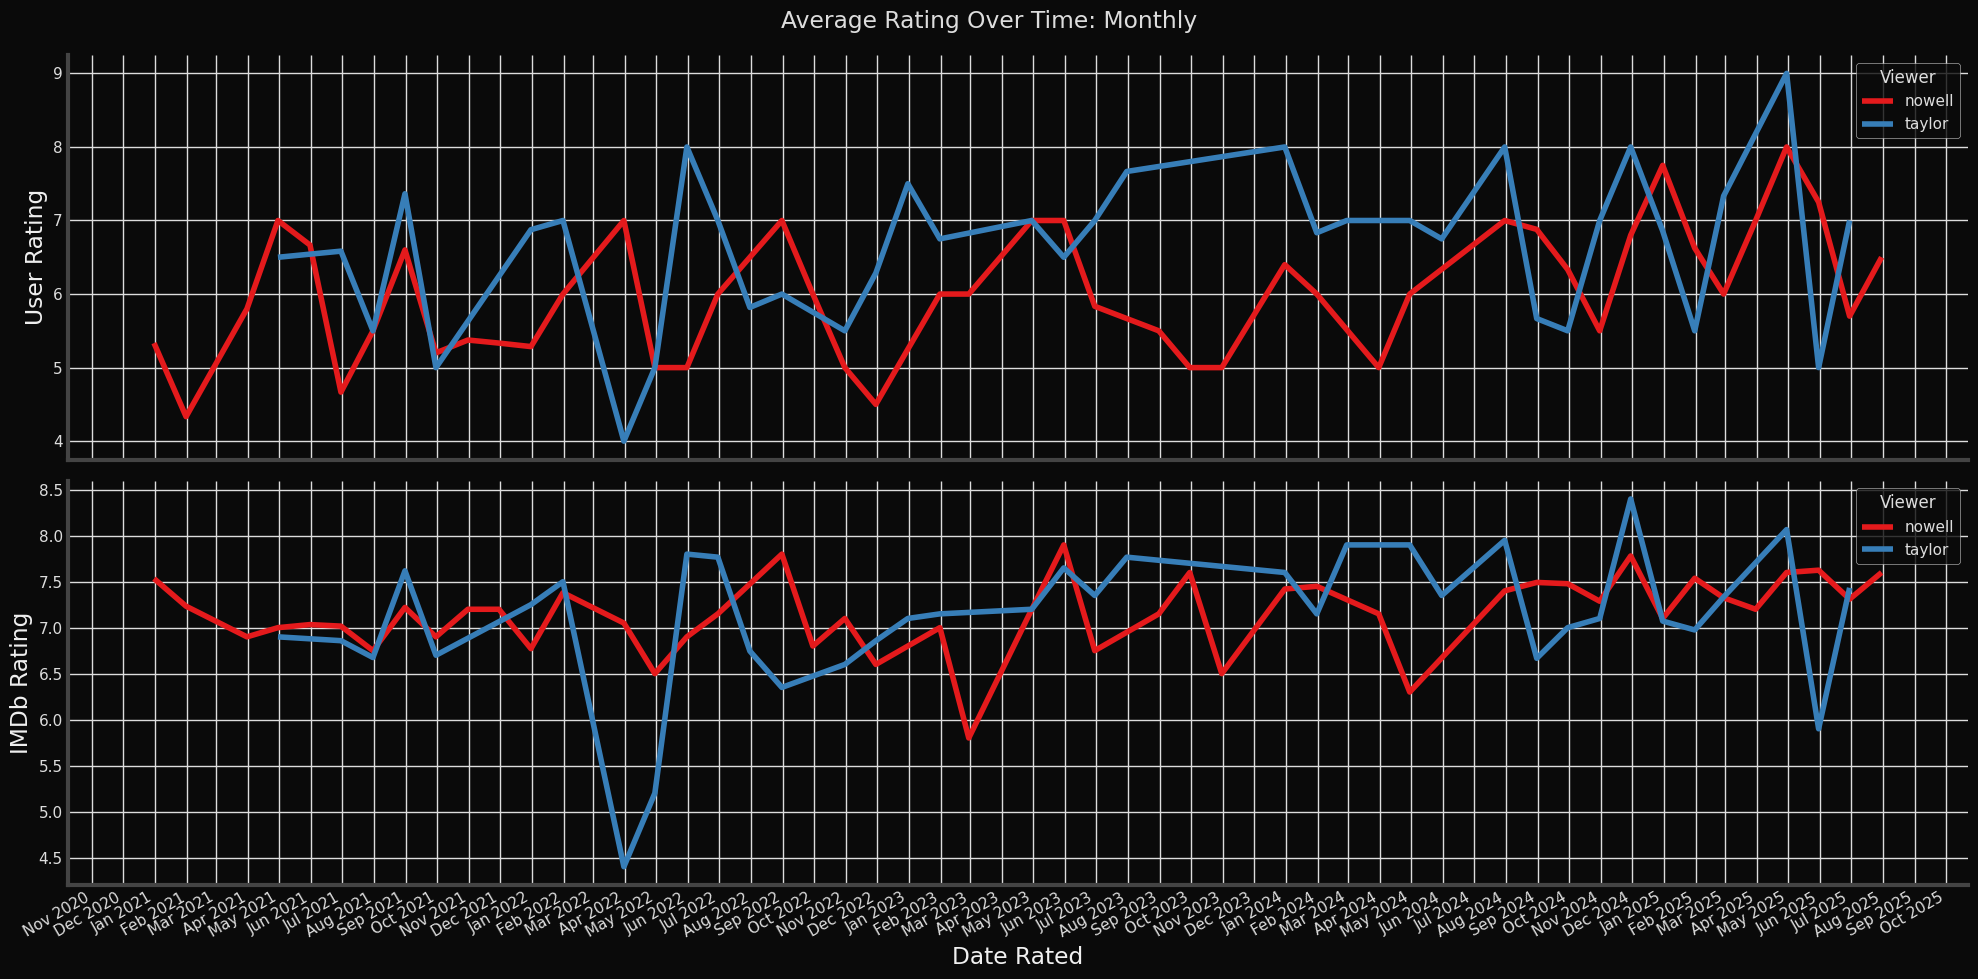

In [ ]:
monthly = (
    df.groupby(['Viewer', pd.Grouper(key='Date Rated', freq='ME')])
      [['User Rating', 'IMDb Rating']].mean()
      .reset_index()
)

fig, (ax1, ax2)=plt.subplots(2,1, figsize=(20, 10), sharex=True)
fig.suptitle('Average Rating Over Time: Monthly')
g=sns.lineplot(monthly,x='Date Rated', y='User Rating', hue='Viewer', ax=ax1)
f=sns.lineplot(monthly,x='Date Rated', y='IMDb Rating', hue='Viewer', ax=ax2)
# Set x-axis to monthly ticks
ax2.xaxis.set_major_locator(mpl_dates.MonthLocator())
ax2.xaxis.set_major_formatter(mpl_dates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

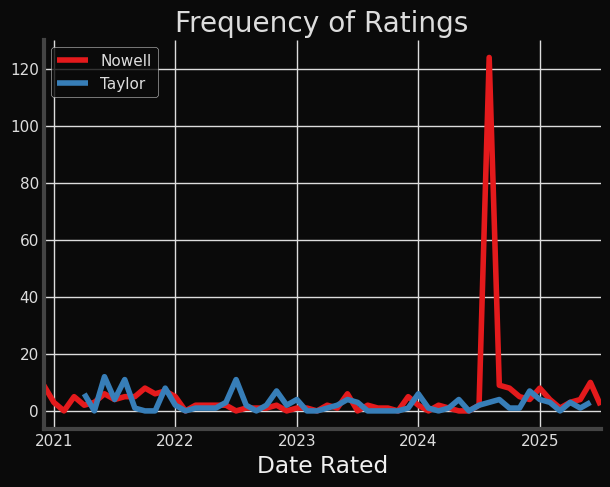

In [ ]:
df[nowell].set_index('Date Rated').resample('ME')['User Rating'].count().plot(
    title='Frequency of Ratings',
    label='Nowell')
df[taylor].set_index('Date Rated').resample('ME')['User Rating'].count().plot(
    title='Frequency of Ratings',
    label='Taylor')
plt.legend()

<Axes: title={'center': 'Frequency of Ratings'}, xlabel='Date Rated'>

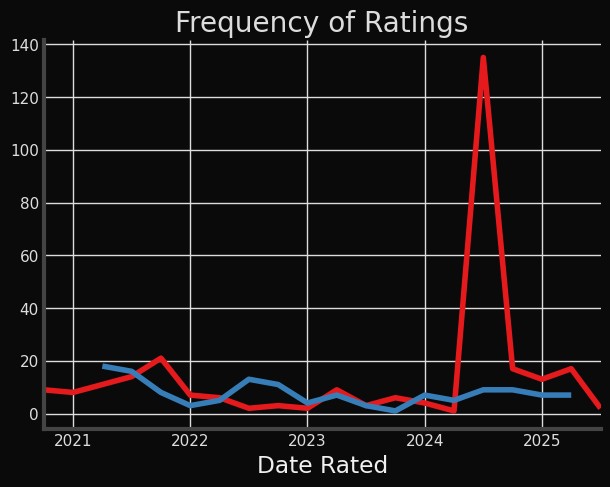

In [ ]:
df[nowell].set_index('Date Rated').resample('QE')['User Rating'].count().plot(title='Frequency of Ratings')
df[taylor].set_index('Date Rated').resample('QE')['User Rating'].count().plot(title='Frequency of Ratings')

In [ ]:
# # Plot average rating by when I rated
# df.groupby('Month Rated')['User Rating'].mean().plot(
#     title='Average Rating by Month Watched',
#     ylabel='My Rating',
#     xlabel='Month (1 = Jan)'
# )

# # Plot average rating by movie's release month
# df.groupby('Release Month')['User Rating'].mean().plot(
#     title='Average Rating by Release Month',
#     ylabel='My Rating',
#     xlabel='Month (1 = Jan)',
#     style='--'
# )

monthly_rating = df.groupby(['Viewer','Release Month']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Title': 'count'
}).rename(columns={'Title': 'Count'}).sort_values(by=['Release Month', 'User Rating'], ascending=False)

# sns.lineplot(x=monthly_rating.index, y=monthly_rating.values)
# plt.title('Average Rating by Month')
# plt.xlabel('Date Rated')
# plt.ylabel('Average Rating')
# plt.show()

monthly_rating.reset_index()


# f=sns.relplot(data=monthly_rating, x='Release Month', y='User Rating', hue='Viewer', kind='line')
# g=sns.relplot(data=monthly_rating, x='Release Month', y='IMDb Rating', hue='Viewer', kind='line')
# .title('Average Rating by Release Month')
plt.show()

Big variation throughout the seasons.

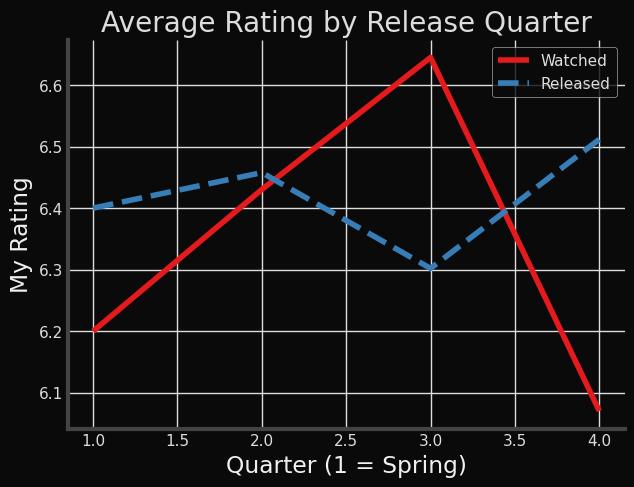

In [ ]:
# Plot average rating by *when I rated*
df.groupby('Season Rated')['User Rating'].mean().plot(
    title='Average Rating by Quarter Watched',
    ylabel='My Rating',
    xlabel='Quarter (1 = Spring)'
)

# Plot average rating by *movie's release month*
df.groupby('Release Season')['User Rating'].mean().plot(
    title='Average Rating by Release Quarter',
    ylabel='My Rating',
    xlabel='Quarter (1 = Spring)',
    style='--'
)
plt.legend(['Watched', 'Released'])

Massive gulf in rating over the summer for release date. Suggests I don't love blockbusters.

In [ ]:
display(df['Release Season'].value_counts())
display(df['Season Rated'].value_counts())

,count
Release Season,
4,129
2,118
3,96
1,80


,count
Season Rated,
3,197
2,86
4,85
1,55


### How mainstream are our tastes?

#### Hot takes

In [ ]:
## Creating filters
favs=(df['User Rating']>df['IMDb Rating'])
goodmv = (df['IMDb Rating']>7)
hottake = abs(df['User Rating'] - df['IMDb Rating']) >=1
tens = df['User Rating']==10

movie_details = df.columns[:8]

In [ ]:
favourite_movies_nowell = df[favs&hottake&nowell][movie_details].sort_values(
    by=['User Rating','Date Rated'], ascending= False)
print("Nowell positive hot takes",favourite_movies_nowell.shape)
favourite_movies_nowell

Nowell positive hot takes (21, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
22,Sinners,7.70,10,nowell,2025-04-18,2025-04-18 21:35:56+00:00,278.58,221.29
112,Spider-Man: Across the Spi...,8.50,10,nowell,2023-06-02,2024-08-29 20:31:27+00:00,381.59,468.14
202,The Prestige,8.50,10,nowell,2006-10-20,2024-08-09 04:48:51+00:00,53.09,1521.17
204,The Dark Knight,9.00,10,nowell,2008-07-18,2024-08-09 04:48:41+00:00,534.99,3044.55
209,Mad Max: Fury Road,8.10,10,nowell,2015-05-15,2024-08-09 04:46:27+00:00,154.28,1174.44
105,Killers of the Flower Moon,7.60,9,nowell,2023-10-20,2024-08-29 20:32:45+00:00,68.04,286.53
109,Moonlight,7.40,9,nowell,2016-11-18,2024-08-29 20:32:10+00:00,27.85,343.88
144,The Raid: Redemption,7.60,9,nowell,2012-04-13,2024-08-29 20:10:31+00:00,4.11,225.07
148,Tenet,7.30,9,nowell,2020-09-03,2024-08-29 20:09:11+00:00,58.50,629.81
157,The Incredibles,8.00,9,nowell,2004-11-05,2024-08-26 19:47:37+00:00,261.44,855.56


In [ ]:
favourite_movies_taylor = df[favs&hottake&taylor][movie_details].sort_values(by=['User Rating','Date Rated'], ascending= False)
print("Taylor positive hot takes",favourite_movies_taylor.shape)
favourite_movies_taylor

Taylor positive hot takes (2, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
23,Sinners,7.70,10,taylor,2025-04-18,2025-04-18 22:20:16+00:00,278.58,221.29
415,Shark Tale,6.00,7,taylor,2004-10-01,2021-06-08 00:00:00+00:00,160.86,205.96


In [ ]:
hottake_nowell = df[hottake&nowell][movie_details].sort_values(by=['User Rating','Date Rated'], ascending= False)
print("Nowell hot takes",hottake_nowell.shape)
hottake_nowell

Nowell hot takes (140, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
22,Sinners,7.70,10,nowell,2025-04-18,2025-04-18 21:35:56+00:00,278.58,221.29
112,Spider-Man: Across the Spi...,8.50,10,nowell,2023-06-02,2024-08-29 20:31:27+00:00,381.59,468.14
202,The Prestige,8.50,10,nowell,2006-10-20,2024-08-09 04:48:51+00:00,53.09,1521.17
204,The Dark Knight,9.00,10,nowell,2008-07-18,2024-08-09 04:48:41+00:00,534.99,3044.55
209,Mad Max: Fury Road,8.10,10,nowell,2015-05-15,2024-08-09 04:46:27+00:00,154.28,1174.44
105,Killers of the Flower Moon,7.60,9,nowell,2023-10-20,2024-08-29 20:32:45+00:00,68.04,286.53
109,Moonlight,7.40,9,nowell,2016-11-18,2024-08-29 20:32:10+00:00,27.85,343.88
144,The Raid: Redemption,7.60,9,nowell,2012-04-13,2024-08-29 20:10:31+00:00,4.11,225.07
148,Tenet,7.30,9,nowell,2020-09-03,2024-08-29 20:09:11+00:00,58.50,629.81
157,The Incredibles,8.00,9,nowell,2004-11-05,2024-08-26 19:47:37+00:00,261.44,855.56


In [ ]:
hottake_taylor = df[hottake&taylor][movie_details].sort_values(by=['User Rating','Date Rated'], ascending= False)
print("Taylor positive hot takes",hottake_taylor.shape)
hottake_taylor

Taylor positive hot takes (28, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
23,Sinners,7.70,10,taylor,2025-04-18,2025-04-18 22:20:16+00:00,278.58,221.29
107,Oppenheimer,8.30,7,taylor,2023-07-21,2024-01-27 00:00:00+00:00,330.08,915.20
406,The Imitation Game,8.00,7,taylor,2014-12-25,2021-08-07 00:00:00+00:00,91.13,857.54
415,Shark Tale,6.00,7,taylor,2004-10-01,2021-06-08 00:00:00+00:00,160.86,205.96
353,Prometheus,7.00,6,taylor,2012-06-08,2024-09-29 18:16:35+00:00,126.48,680.20
355,A Quiet Place,7.50,6,taylor,2018-04-06,2024-08-22 20:32:36+00:00,188.02,634.52
230,Coraline,7.80,6,taylor,2009-02-06,2024-08-21 14:15:27+00:00,116.90,286.73
359,War for the Planet of the ...,7.40,6,taylor,2017-07-14,2024-05-17 00:00:00+00:00,146.88,317.26
126,Prey,7.10,6,taylor,2022-08-05,2023-06-14 00:00:00+00:00,NaN,253.83
235,Moana,7.60,6,taylor,2016-11-23,2023-05-20 00:00:00+00:00,248.76,420.93


In [ ]:
# Using SD to find the outliers
df['Difference'] = df['User Rating'] - df['IMDb Rating']

mean_diff = df['Difference'].mean()
std_diff = df['Difference'].std()

threshold = 2 * std_diff
df['Hot_Take'] = df['Difference'].abs() > threshold

# Add labels
def label_hot_take(row):
    if row['Difference'] > threshold:
        return 'Overrated'
    elif row['Difference'] < -threshold:
        return 'Underrated'
    else:
        return 'Normal'

df['Hot_Take_Label'] = df.apply(label_hot_take, axis=1)

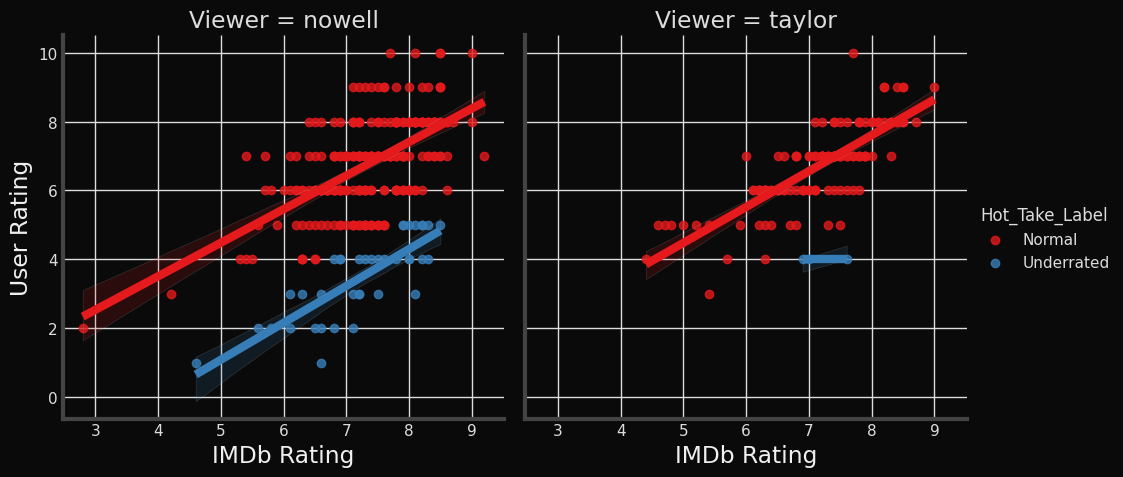

In [ ]:
sns.lmplot(data=df, x='IMDb Rating', y='User Rating',
                hue='Hot_Take_Label',col='Viewer')
# plt.plot([0, 10], [0, 10], linestyle='--', color='gray')  # Line of fit
# fig.title('User Ratings vs IMDb Rating')
fig.legend(title='Hot Take Status')
plt.show()

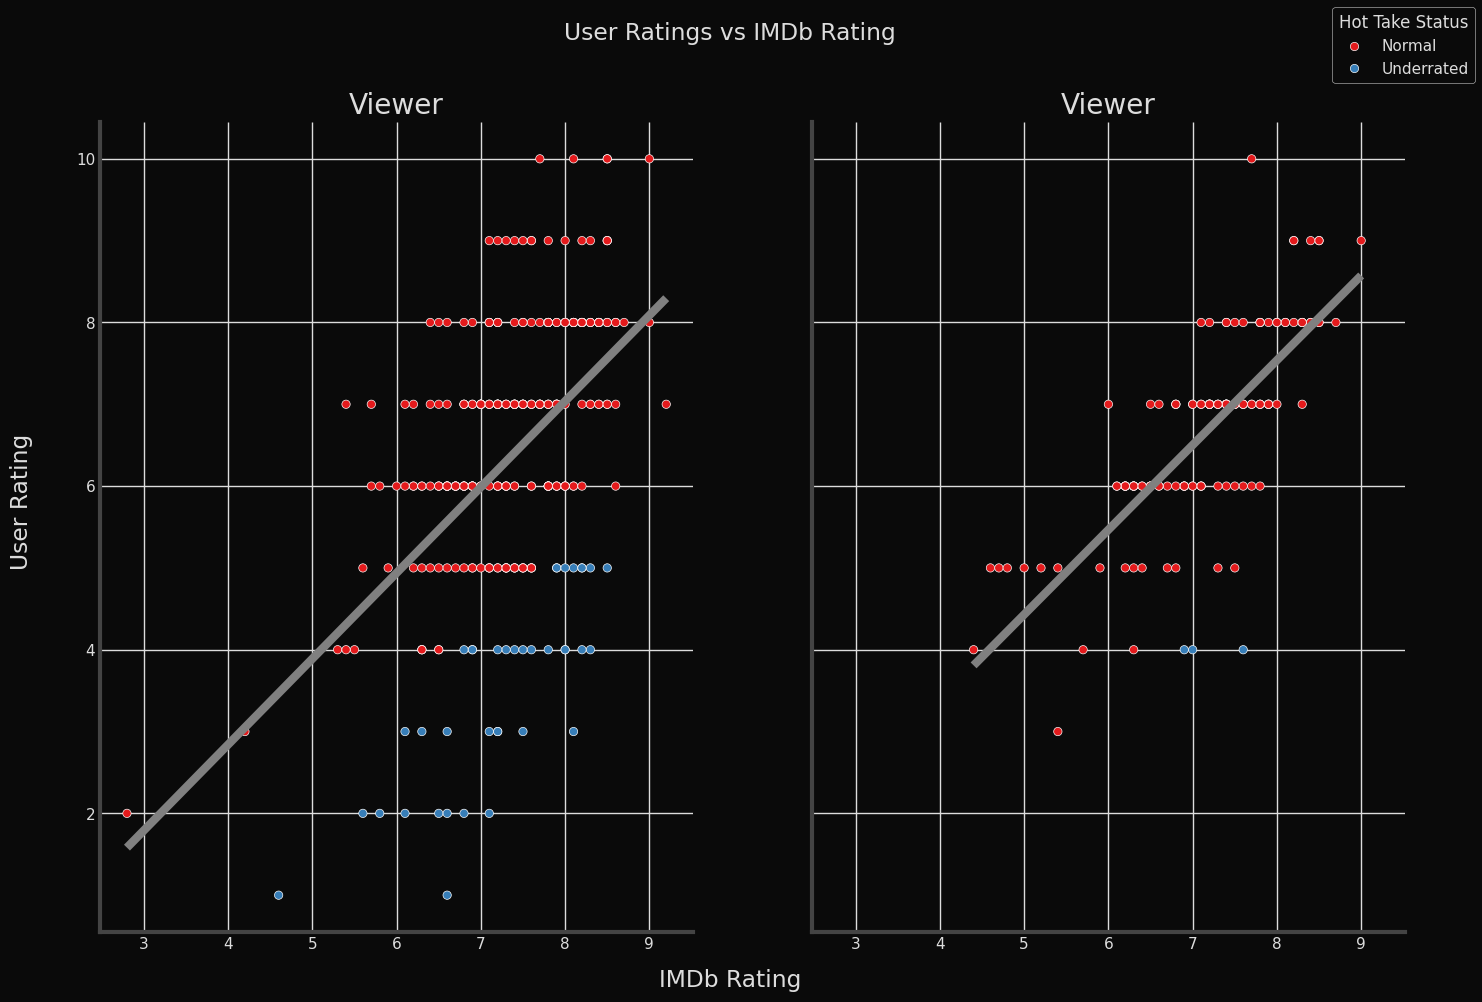

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10), sharey=True, sharex=True)
# sns.scatterplot(data=df[nowell], x='IMDb Rating', y='User Rating',
#                 hue='Hot_Take_Label', ax=ax1)
# sns.scatterplot(data=df[taylor], x='IMDb Rating', y='User Rating',
#                 hue='Hot_Take_Label', legend=False,
#                 ax=ax2)
# fig.suptitle('User Ratings vs IMDb Rating')
# fig.supxlabel('IMDb Rating')
# fig.supylabel('User Rating')
# ax1.legend_.remove()
# ax1.set_xlabel(None)
# ax1.set_ylabel(None)
# ax2.set_xlabel(None)
# ax2.set_ylabel(None)
# fig.legend(title='Hot Take Status')
# plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = [ax1, ax2]
viewers = [nowell, taylor]

for ax, viewer in zip(axes, viewers):
    sns.scatterplot(data=df[viewer], x='IMDb Rating', y='User Rating',
                    hue='Hot_Take_Label', ax=ax)
    sns.regplot(data=df[viewer], x='IMDb Rating', y='User Rating',
                scatter=False, ax=ax, color='gray', marker="o", ci=None)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.legend_.remove()
    ax.set_title(f'{viewer.name.capitalize()}')

fig.suptitle('User Ratings vs IMDb Rating')
fig.supxlabel('IMDb Rating')
fig.supylabel('User Rating')

fig.legend(*ax1.get_legend_handles_labels(), title='Hot Take Status')
plt.show()


#### Votes

In [ ]:
df.groupby('Viewer')['Num Votes'].describe()

,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,290.00,439992.60,447407.65,1709.00,121364.75,303491.00,594335.75,3044547.00
taylor,133.00,441434.47,448109.27,496.00,156931.00,315980.00,594972.00,3044547.00


In [ ]:
# Most popular movies in the df
display(df[nowell][movie_details].sort_values(by = 'Num Votes Thousands',ascending=False).style.set_table_styles([
    {'selector': 'thead th', 'props': 'position: sticky; top:0; background-color:red;'}]))
display(df[taylor][movie_details].sort_values(by = 'Num Votes Thousands',ascending=False).head(30))

,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
204,The Dark Knight,9.000000,10,nowell,2008-07-18 00:00:00,2024-08-09 04:48:41+00:00,534.987076,3044.547000
48,The Godfather,9.200000,7,nowell,1972-03-24 00:00:00,2024-11-01 19:39:44+00:00,136.381073,2142.249000
37,The Dark Knight Rises,8.400000,8,nowell,2012-07-20 00:00:00,2025-01-03 17:39:58+00:00,448.149584,1926.092000
16,Django Unchained,8.500000,9,nowell,2012-12-25 00:00:00,2025-05-19 19:33:35+00:00,162.805434,1806.256000
164,Gladiator,8.500000,7,nowell,2000-05-05 00:00:00,2024-08-10 07:52:49+00:00,187.705427,1777.497000
147,Inglourious Basterds,8.400000,8,nowell,2009-08-21 00:00:00,2024-08-29 20:09:36+00:00,120.540719,1701.388000
221,Batman Begins,8.200000,8,nowell,2005-06-15 00:00:00,2024-07-29 19:22:37+00:00,206.863479,1659.219000
91,The Silence of the Lambs,8.600000,8,nowell,1991-02-14 00:00:00,2024-08-29 20:39:01+00:00,130.742922,1649.188000
78,Joker,8.300000,4,nowell,2019-10-04 00:00:00,2024-08-30 06:56:47+00:00,335.477657,1619.842000
6,Shutter Island,8.200000,5,nowell,2010-02-19 00:00:00,2025-06-03 19:43:59+00:00,128.012934,1563.854000


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
205,The Dark Knight,9.00,9,taylor,2008-07-18,2021-08-02 00:00:00+00:00,534.99,3044.55
407,The Matrix,8.70,8,taylor,1999-03-31,2021-08-02 00:00:00+00:00,172.08,2170.12
17,Django Unchained,8.50,8,taylor,2012-12-25,2021-04-04 00:00:00+00:00,162.81,1806.26
203,The Prestige,8.50,9,taylor,2006-10-20,2021-12-23 00:00:00+00:00,53.09,1521.17
219,Memento,8.40,8,taylor,2001-05-25,2024-11-18 15:41:38+00:00,25.54,1389.29
398,Avengers: Endgame,8.40,9,taylor,2019-04-26,2021-12-19 00:00:00+00:00,858.37,1373.63
357,Avengers: Infinity War,8.40,8,taylor,2018-04-27,2024-07-11 13:45:20+00:00,678.82,1301.79
217,The Truman Show,8.20,8,taylor,1998-06-05,2021-04-09 00:00:00+00:00,125.62,1300.20
201,Parasite,8.50,8,taylor,2019-11-08,2021-08-02 00:00:00+00:00,53.85,1079.71
412,"Monsters, Inc.",8.10,8,taylor,2001-11-23,2021-06-11 00:00:00+00:00,290.64,1036.80


In [ ]:
# Least popular movies in the df
display(df[nowell][movie_details].sort_values(by = 'Num Votes Thousands',ascending=True).head(30))
display(df[taylor][movie_details].sort_values(by = 'Num Votes Thousands',ascending=True).head(30))

,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
1,KPop Demon Hunters,7.90,7,nowell,2025-06-20,2025-07-01 11:56:19+00:00,NaN,1.71
165,The Lorax,7.90,7,nowell,1972-02-14,2024-08-10 07:52:34+00:00,NaN,3.54
342,Dave Chappelle: 8:46,8.10,8,nowell,2020-06-12,2020-12-16 00:00:00+00:00,NaN,3.94
268,Hilda and the Mountain King,7.70,7,nowell,2021-12-30,2022-01-30 00:00:00+00:00,NaN,4.18
88,Konosuba!: God's Blessing ...,7.80,8,nowell,2019-08-30,2024-08-30 06:55:24+00:00,1.13,6.24
162,Ultraman: Rising,6.90,6,nowell,2024-06-14,2024-08-16 12:17:31+00:00,NaN,6.53
32,Humanist Vampire Seeking C...,7.00,7,nowell,2024-02-15,2025-01-18 20:08:50+00:00,0.02,8.74
334,Blue Story,6.30,4,nowell,2020-05-05,2020-12-22 00:00:00+00:00,NaN,8.97
249,Falcon Rising,5.80,6,nowell,2014-09-04,2023-02-27 00:00:00+00:00,0.01,9.46
305,Steins;Gate: The Movie - L...,7.80,6,nowell,2013-04-20,2021-08-27 00:00:00+00:00,NaN,10.63


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
421,The Weekend,4.60,5,taylor,2016-12-02,2021-04-05 00:00:00+00:00,NaN,0.50
381,A Jazzman's Blues,6.80,6,taylor,2022-09-23,2022-10-10 00:00:00+00:00,NaN,4.55
400,Come Away,5.70,4,taylor,2020-11-13,2021-12-18 00:00:00+00:00,0.18,6.01
385,Nobody's Fool,5.00,5,taylor,2018-11-02,2022-07-14 00:00:00+00:00,31.71,8.27
362,The Kitchen,4.80,5,taylor,2024-01-19,2024-01-19 00:00:00+00:00,NaN,8.68
335,Blue Story,6.30,6,taylor,2020-05-05,2021-12-05 00:00:00+00:00,NaN,8.97
395,Fat Albert,4.40,4,taylor,2004-12-25,2022-03-12 00:00:00+00:00,48.12,13.37
380,Wendell & Wild,6.40,5,taylor,2022-10-28,2022-10-29 00:00:00+00:00,NaN,13.98
383,Look Both Ways,6.30,6,taylor,2022-08-17,2022-08-21 00:00:00+00:00,NaN,25.93
423,Someone Great,6.20,5,taylor,2019-04-19,2021-04-04 00:00:00+00:00,NaN,26.10


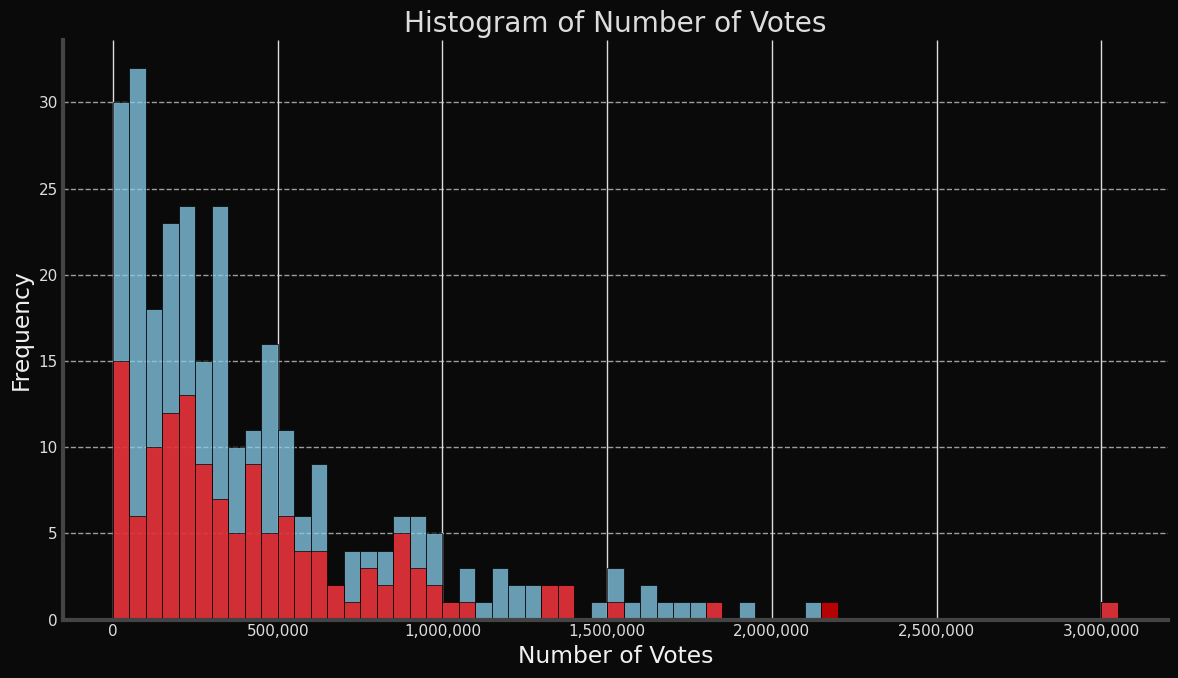

In [ ]:
# Calculate maximum for binning
max_votes = df['Num Votes'].max()

# Custom bin width
bin_width = 50000
bins = range(0, int(max_votes) + bin_width, bin_width)

plt.figure(figsize=(12, 7))

sns.histplot(df[nowell]['Num Votes'], bins=bins,
             color='skyblue', edgecolor='black',
             label='Nowell')
sns.histplot(df[taylor]['Num Votes'], bins=bins,
             color='red', edgecolor='black',
             alpha=0.7, label='Taylor')

# Format x-axis labels with thousand separators
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.xlabel('Number of Votes')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Votes')

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<Axes: xlabel='Num Votes Thousands', ylabel='User Rating'>

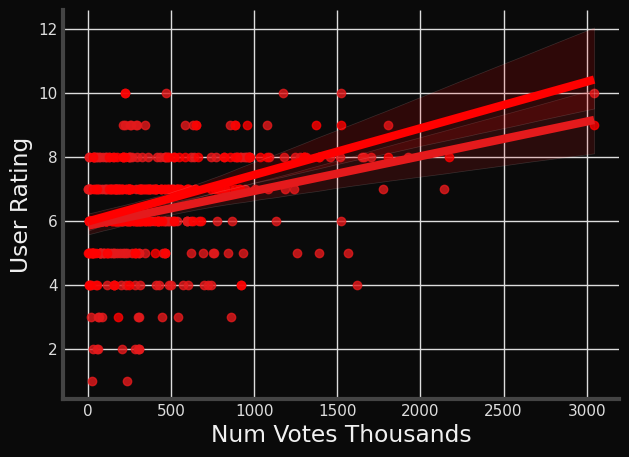

In [ ]:
sns.regplot(data=df[nowell], x='Num Votes Thousands', y='User Rating')
sns.regplot(data=df[taylor], x='Num Votes Thousands', y='User Rating', color='red')

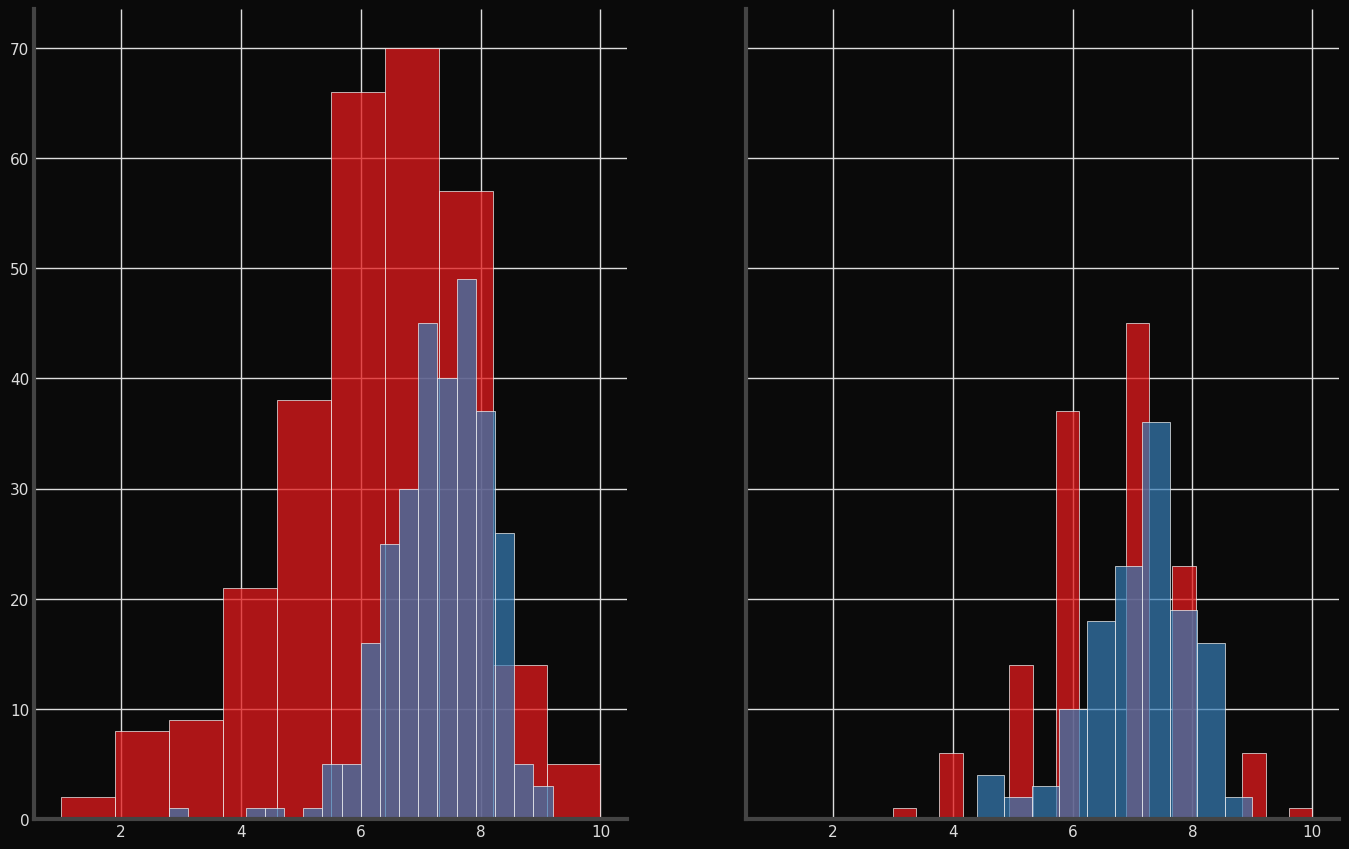

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = [ax1, ax2]
viewers = [nowell, taylor]

for ax, viewer in zip(axes, viewers):
    sns.histplot(data=df[viewer], x='User Rating',
                ax=ax)
    sns.histplot(data=df[viewer], x='IMDb Rating',
                ax=ax, alpha=0.7)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    # ax.legend_.remove()

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10), sharey=True)
# g=sns.histplot(df.loc[nowell]['User Rating'],
#              bins=20, ax=ax1,
#              color='skyblue', edgecolor='black',
#              label = 'Nowell rating', legend=True)
# f=sns.histplot(df['IMDb Rating'],
#                bins=20, color='orange', edgecolor='black',
#                alpha=0.7, ax=ax1,
#                label = 'IMDb Rating', legend=True)

# sns.histplot(df.loc[taylor]['User Rating'],
#              bins=20,  binrange=(1,10),
#              color='red', edgecolor='black',
#              label = 'Taylor rating', ax=ax2)
# sns.histplot(df['IMDb Rating'],
#              bins=20, color='orange', edgecolor='black',
#              alpha=0.7, ax=ax2,
#              label = 'IMDb Rating', legend=True)
# fig.suptitle('Distribution of Ratings')
# fig.supxlabel('Rating')
# fig.supylabel('Frequency')
# ax1.set_xlabel(None)
# ax1.set_ylabel(None)
# ax2.set_xlabel(None)
# ax2.set_ylabel(None)
# fig.legend(loc='upper right', ncols=2)
# plt.tight_layout()
# plt.show()

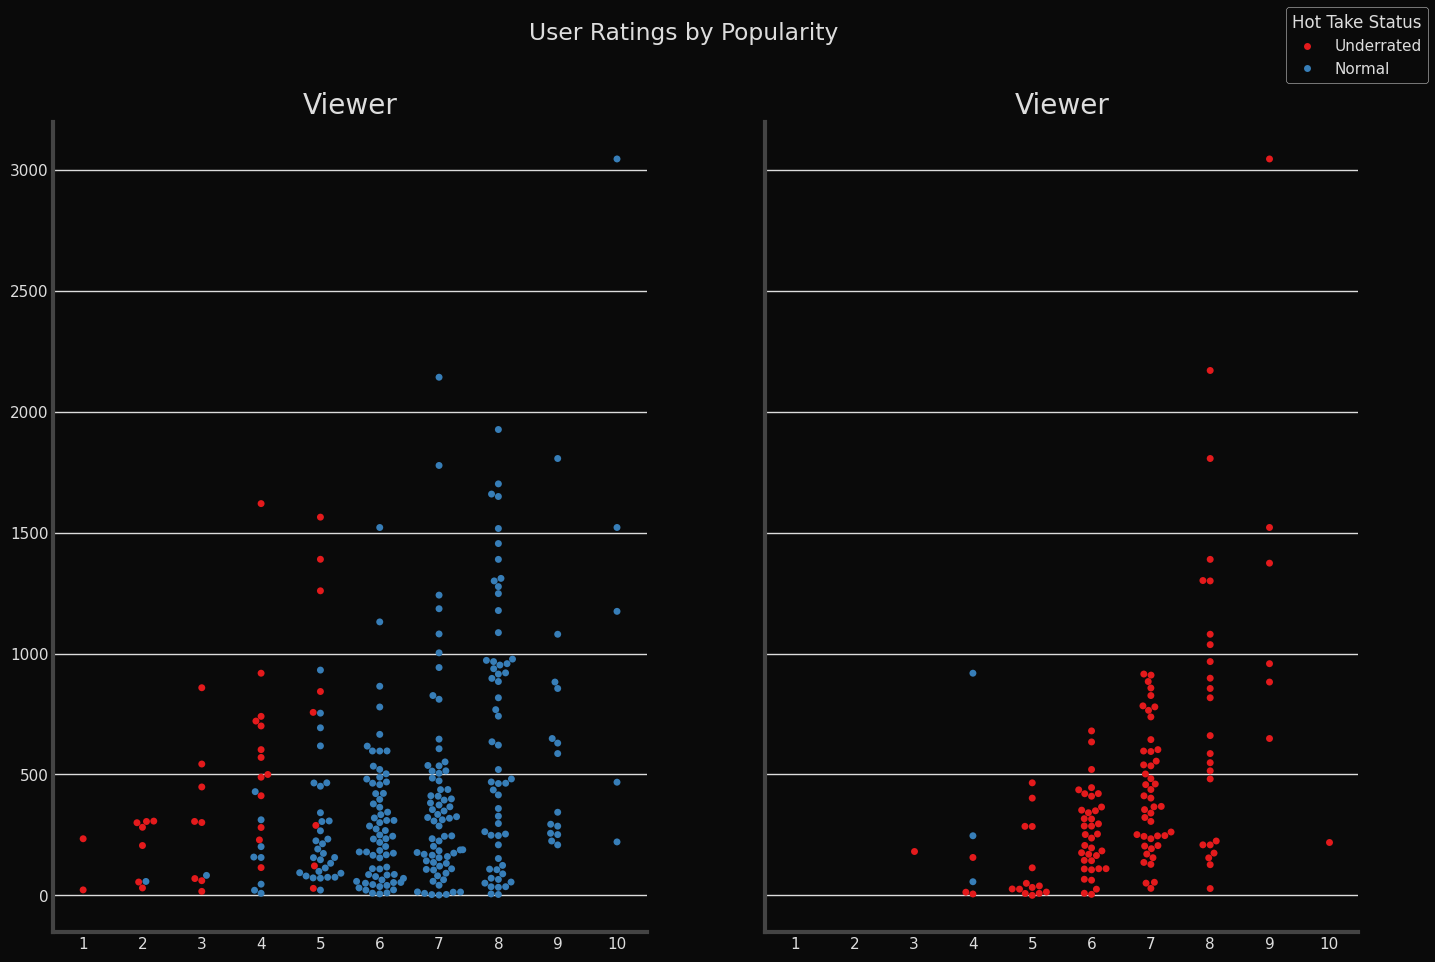

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = [ax1, ax2]
viewers = [nowell, taylor]

for ax, viewer in zip(axes, viewers):
    sns.swarmplot(data=df[viewer], y='Num Votes Thousands', x='User Rating',
                hue='Hot_Take_Label', ax=ax)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.legend_.remove()
    ax.set_title(f'{viewer.name.capitalize()}')

fig.suptitle('User Ratings by Popularity')
# fig.supxlabel('IMDb Rating')
# fig.supylabel('User Rating')

fig.legend(*ax1.get_legend_handles_labels(), title='Hot Take Status')
plt.show()

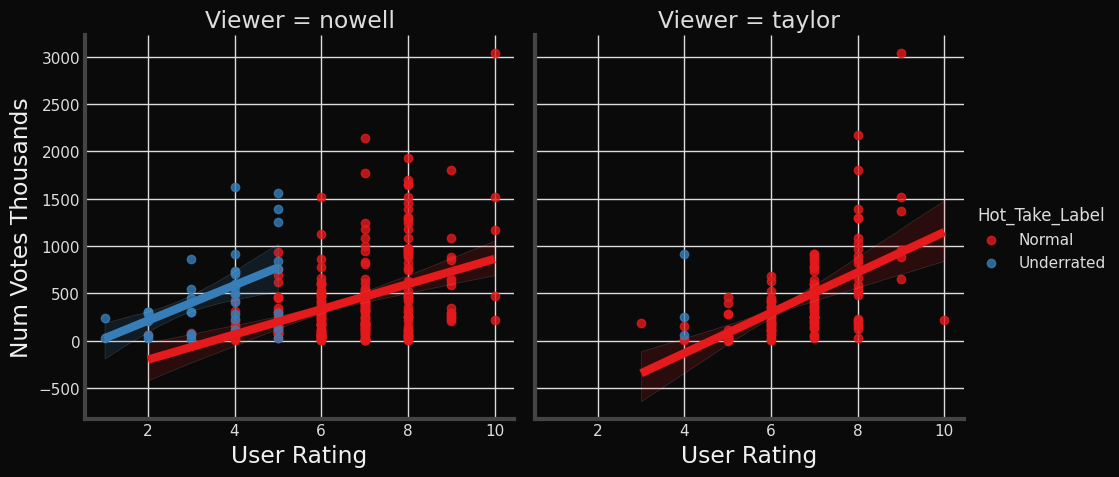

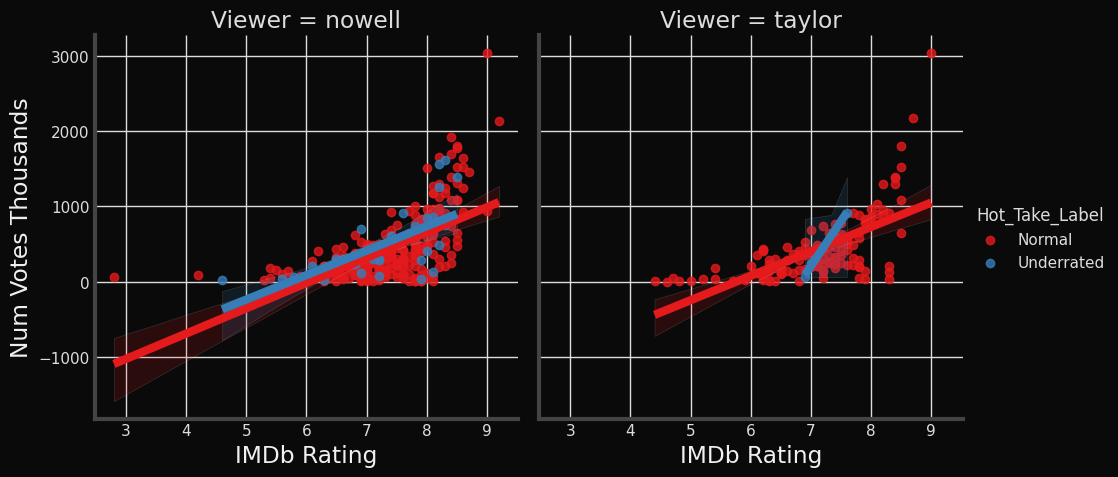

In [ ]:
sns.lmplot(data=df, y='Num Votes Thousands', x='User Rating',
           col= 'Viewer', hue='Hot_Take_Label')
sns.lmplot(data=df, y='Num Votes Thousands', x='IMDb Rating',
           col= 'Viewer', hue='Hot_Take_Label')

#### Box Office

In [ ]:
df.groupby('Viewer')['Box Office Millions'].describe()

,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,256.00,122.51,147.43,0.01,27.54,70.18,163.83,936.66
taylor,120.00,182.87,168.45,0.07,65.14,150.01,229.39,858.37


In [ ]:
display(df[nowell][movie_details].sort_values(by='Box Office Millions', ascending=False).head(20))
display(df[taylor][movie_details].sort_values(by='Box Office Millions', ascending=False).head(20))

,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
307,Star Wars: Episode VII - T...,7.80,7,nowell,2015-12-18,2021-07-25 00:00:00+00:00,936.66,1002.98
131,Spider-Man: No Way Home,8.20,8,nowell,2021-12-17,2024-08-29 20:13:02+00:00,814.87,958.08
92,Inside Out 2,7.50,5,nowell,2024-06-14,2024-08-29 20:38:53+00:00,652.98,225.84
62,Deadpool & Wolverine,7.50,7,nowell,2024-07-26,2024-09-15 13:53:13+00:00,636.75,515.16
187,Barbie,6.80,6,nowell,2023-07-21,2024-08-09 05:35:52+00:00,636.24,617.25
191,The Avengers,8.00,8,nowell,2012-05-04,2024-08-09 05:35:25+00:00,623.36,1516.93
71,Star Wars: Episode VIII - ...,6.90,4,nowell,2017-12-15,2024-08-30 06:59:27+00:00,620.18,700.59
204,The Dark Knight,9.00,10,nowell,2008-07-18,2024-08-09 04:48:41+00:00,534.99,3044.55
34,Wicked,7.40,7,nowell,2024-11-22,2025-01-15 17:53:04+00:00,473.23,174.99
155,Star Wars: Episode IV - A ...,8.60,6,nowell,1977-05-25,2024-08-29 19:42:04+00:00,461.00,1521.04


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
398,Avengers: Endgame,8.40,9,taylor,2019-04-26,2021-12-19 00:00:00+00:00,858.37,1373.63
132,Spider-Man: No Way Home,8.20,9,taylor,2021-12-17,2021-12-18 00:00:00+00:00,814.87,958.08
371,Avatar: The Way of Water,7.50,7,taylor,2022-12-16,2023-01-14 00:00:00+00:00,684.08,539.76
357,Avengers: Infinity War,8.40,8,taylor,2018-04-27,2024-07-11 13:45:20+00:00,678.82,1301.79
63,Deadpool & Wolverine,7.50,8,taylor,2024-07-26,2024-07-26 09:01:36+00:00,636.75,515.16
364,Incredibles 2,7.50,7,taylor,2018-06-15,2023-07-02 00:00:00+00:00,608.58,354.78
344,The Lion King,6.80,5,taylor,2019-07-19,2025-01-05 20:29:47+00:00,543.64,285.03
205,The Dark Knight,9.00,9,taylor,2008-07-18,2021-08-02 00:00:00+00:00,534.99,3044.55
35,Wicked,7.40,8,taylor,2024-11-22,2025-02-13 00:39:58+00:00,473.23,174.99
321,Shrek 2,7.40,7,taylor,2004-05-19,2021-06-01 00:00:00+00:00,444.98,535.72


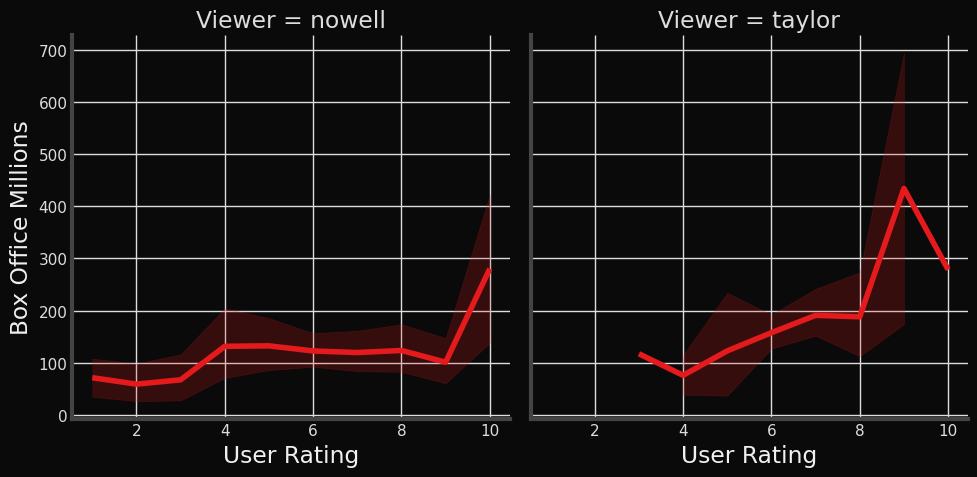

In [ ]:
sns.relplot(data=df, y='Box Office Millions', x='User Rating', kind='line',
            col='Viewer')
# ylog_scale = True
# plt.yscale('log')

<Axes: xlabel='IMDb Rating', ylabel='Box Office Millions'>

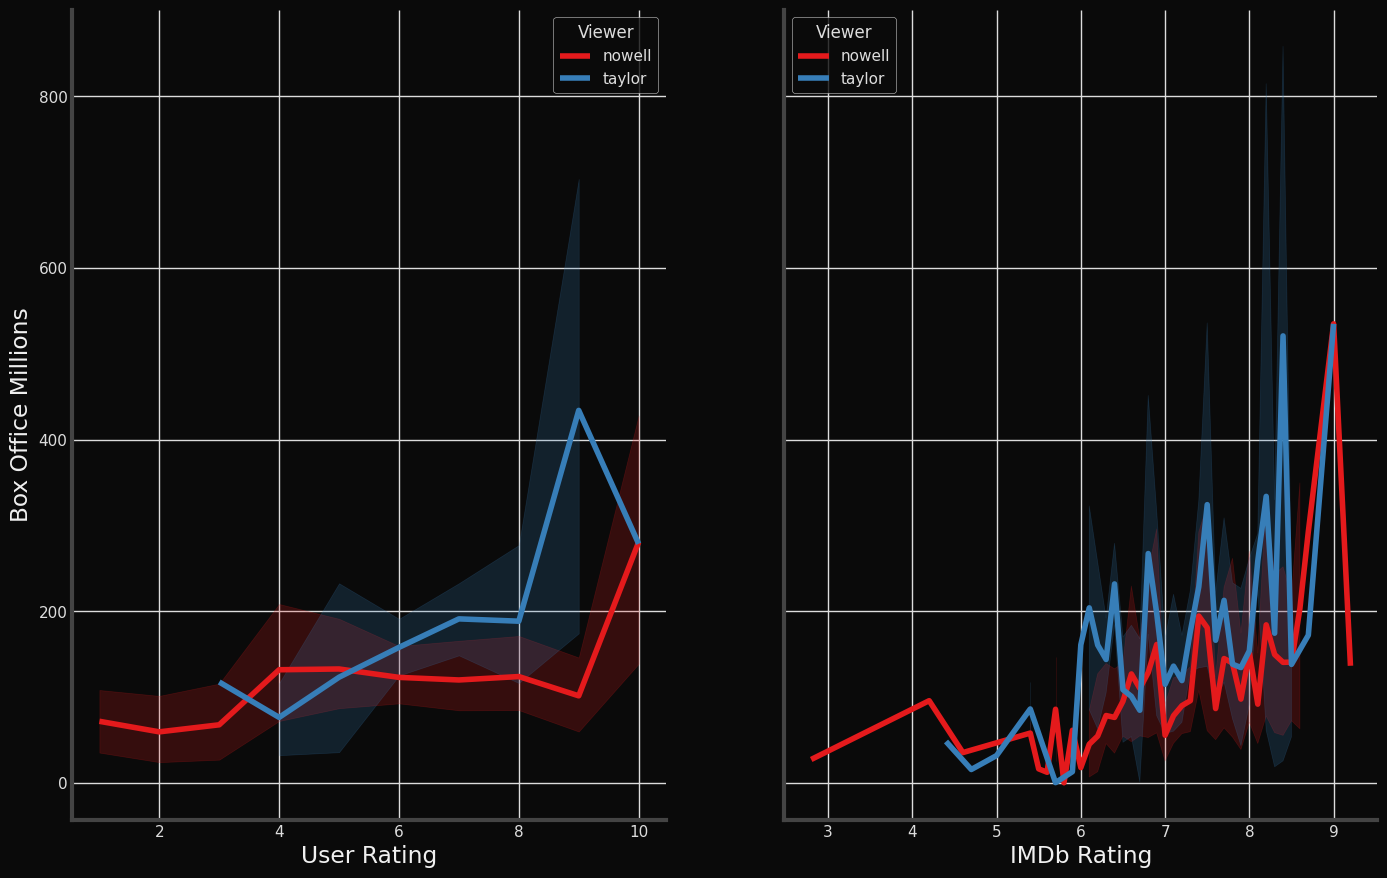

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10), sharey=True)
sns.lineplot(data=df, x='User Rating', y='Box Office Millions', hue='Viewer', ax=ax1)
sns.lineplot(data=df, x='IMDb Rating', y='Box Office Millions', hue='Viewer', ax=ax2)

#### Country

In [ ]:
country_avg_rating = df_country.groupby(['Country','Viewer']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Box Office Millions': 'mean',
    'Num Votes Thousands': 'mean',
    'Title': 'count'
}).rename(columns={'Title':'Count'}).sort_values(by='Count',ascending=False).reset_index()

import plotly.express as px

fig = px.choropleth(country_avg_rating,
                    locations='Country',
                    locationmode='country names',
                    color='Count',
                    hover_name='Country',
                    facet_col='Viewer',
                    hover_data={
        'User Rating': ':.2f',
        'IMDb Rating': ':.2f',
        'Box Office Millions': ':.2f',
        'Num Votes Thousands': ':.2f',
        'Count': True,
        # 'Viewer': True
    },
                    title='Number of Movies by Country',
                    color_continuous_scale='Viridis_r')
fig.show()


### Movies Standardised

In [ ]:
# Movies standardised

same_movies = pd.merge(df[nowell], df[taylor]['Title'], on='Title', how='inner')

same_movies.shape
# Only ~50 movies we've both seen so can't correlate our ratings

(52, 39)

In [ ]:
print(same_movies['Title'])

0                     The Favourite
1              Crazy, Stupid, Love.
2                     Lilo & Stitch
3                  Django Unchained
4                           Sinners
5                            Wicked
6                    Predestination
7               The Prince of Egypt
8            A Quiet Place: Day One
9              Deadpool & Wolverine
10                      Blink Twice
11    Once Upon a Time... in Hol...
12    Kingdom of the Planet of t...
13                         Saltburn
14                      Oppenheimer
15     Puss in Boots: The Last Wish
16                       The Batman
17                      Glass Onion
18                             Prey
19          Spider-Man: No Way Home
20                       Knives Out
21                The Suicide Squad
22                        Prisoners
23             The Raid: Redemption
24                  The Incredibles
25                            Focus
26                         Eternals
27                   Dune: P

In [ ]:
display(df.groupby('Viewer')['User Rating'].describe())
display(df.groupby('Viewer')['IMDb Rating'].describe())

,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,290.00,6.33,1.72,1.00,5.00,7.00,8.00,10.00
taylor,133.00,6.63,1.23,3.00,6.00,7.00,7.00,10.00


,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,290.00,7.33,0.83,2.80,6.83,7.40,7.90,9.20
taylor,133.00,7.12,0.89,4.40,6.50,7.20,7.70,9.00


## Statistics Testing

In [ ]:
df.groupby('Viewer')['Runtime (Mins)'].describe()

,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,290.00,115.01,23.79,25.00,100.00,113.00,130.00,206.00
taylor,133.00,117.11,24.17,65.00,98.00,114.00,131.00,192.00


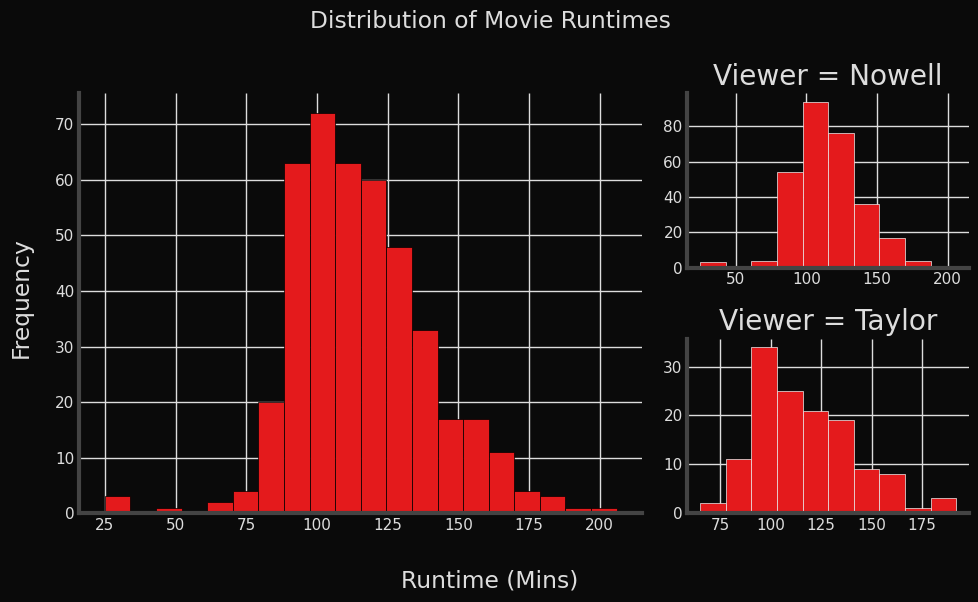

In [ ]:
# Distribution of movie runtimes
# Setting mosaic figure
fig, axs = plt.subplot_mosaic([['left', 'upper right'],
                               ['left', 'lower right']],
                              figsize=(10, 6),
                              gridspec_kw={'width_ratios': [2, 1]})
# Plotting
axs['left'].hist(df['Runtime (Mins)'], bins=20, edgecolor='black')
axs['upper right'].hist(x='Runtime (Mins)', data=df[nowell])
axs['lower right'].hist(x='Runtime (Mins)', data=df[taylor])
# Setting labels
# axs['left'].set_xlabel('Runtime (Mins)')
axs['upper right'].set_title('Viewer = Nowell')
axs['lower right'].set_title('Viewer = Taylor')
fig.supxlabel('Runtime (Mins)')
fig.supylabel('Frequency')
fig.suptitle('Distribution of Movie Runtimes')
plt.tight_layout()
plt.show()

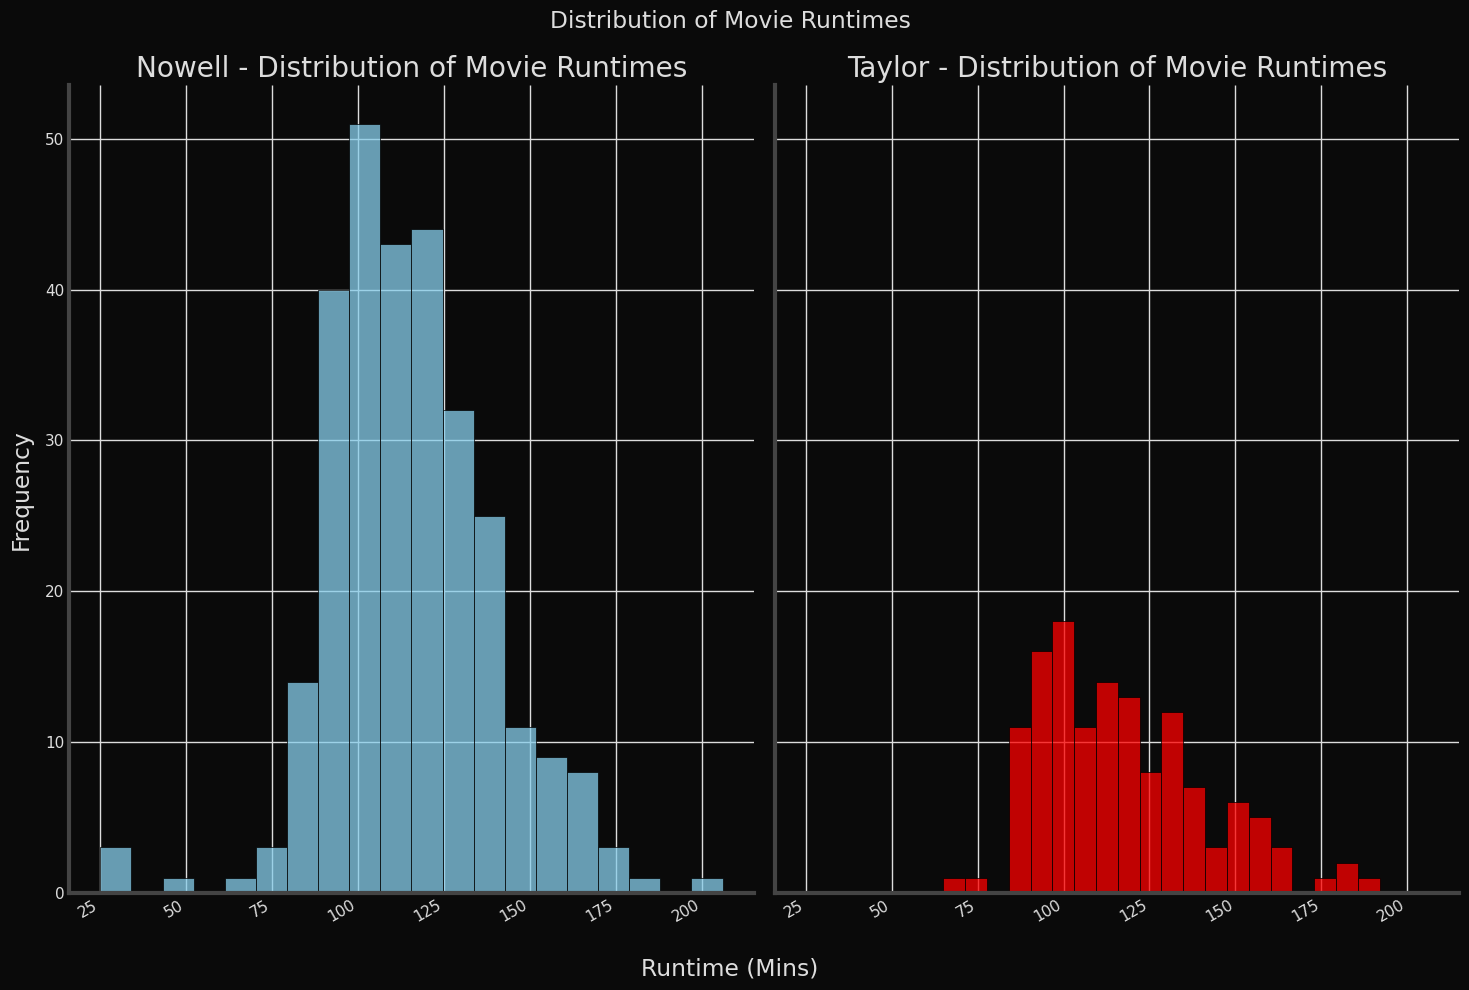

In [ ]:
# Distribution of movie runtimes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10), sharex=True, sharey=True)
g=sns.histplot(df[nowell]['Runtime (Mins)'], bins=20,
               color='skyblue', edgecolor='black',
               ax=ax1, label='Nowell')
f=sns.histplot(df[taylor]['Runtime (Mins)'], bins=20,
               color='red', edgecolor='black',
               ax=ax2, label = 'Taylor rating')
ax1.set_title('Nowell - Distribution of Movie Runtimes')
ax2.set_title('Taylor - Distribution of Movie Runtimes')
fig.supxlabel('Runtime (Mins)')
fig.supylabel('Frequency')
fig.suptitle('Distribution of Movie Runtimes')
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax2.set_xlabel(None)
ax2.set_ylabel(None)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
df['Runtime Category'] = pd.cut(
    df['Runtime (Mins)'],
    bins=[0, 90, 120, float('inf')],
    labels=['Short', 'Medium', 'Long'])
df['Runtime Category'].value_counts()

,count
Runtime Category,
Medium,226
Long,155
Short,42


In [ ]:
from scipy.stats import shapiro
display(shapiro(df['Runtime Category']=='Short'))
display(shapiro(df['Runtime Category']=='Medium'))
display(shapiro(df['Runtime Category']=='Long'))

ShapiroResult(statistic=np.float64(0.34064351473597143), pvalue=np.float64(2.6254805204656362e-36))

ShapiroResult(statistic=np.float64(0.6348149513167552), pvalue=np.float64(5.105718510537657e-29))

ShapiroResult(statistic=np.float64(0.6100398864371883), pvalue=np.float64(8.72213037739069e-30))

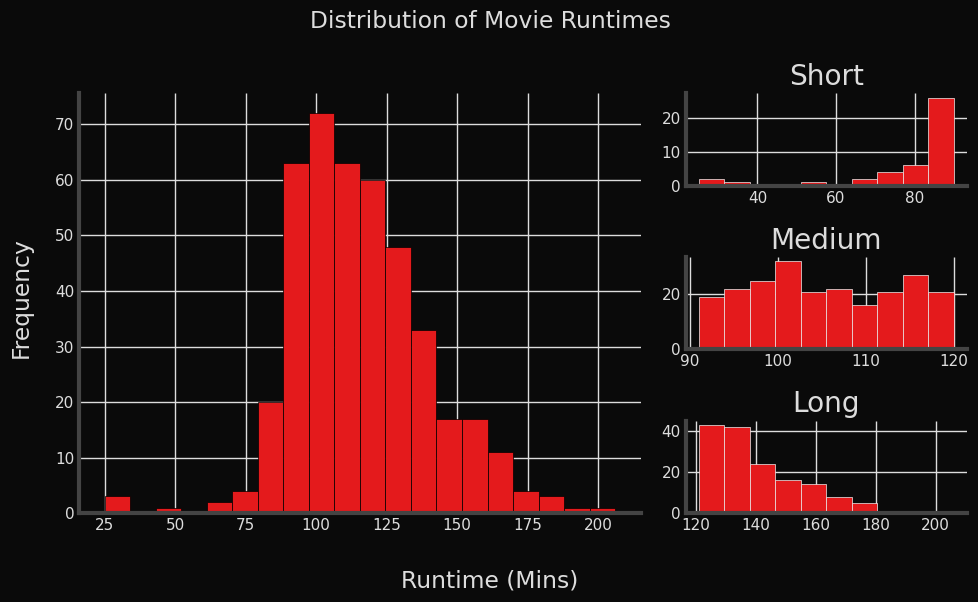

In [ ]:
fig, axs = plt.subplot_mosaic([['left', 'upper right'],
                               ['left', 'center right'],
                               ['left', 'lower right']],
                              figsize=(10, 6),
                              gridspec_kw={'width_ratios': [2, 1]})
axs['left'].hist(df['Runtime (Mins)'], bins=20, edgecolor='black')
axs['upper right'].hist(x='Runtime (Mins)', data=df[df['Runtime Category'] == 'Short'])
axs['center right'].hist(x='Runtime (Mins)', data=df[df['Runtime Category']== 'Medium'])
axs['lower right'].hist(x='Runtime (Mins)', data=df[df['Runtime Category']== 'Long'])
# axs['left'].set_xlabel('Runtime (Mins)')
# axs['left'].set_ylabel('Frequency')
# axs['left'].set_title('Distribution of Movie Runtimes')
axs['upper right'].set_title('Short')
axs['center right'].set_title('Medium')
axs['lower right'].set_title('Long')
fig.supxlabel('Runtime (Mins)')
fig.supylabel('Frequency')
fig.suptitle('Distribution of Movie Runtimes')
plt.tight_layout()
plt.show()

The distributions are all too different for a parametric test.

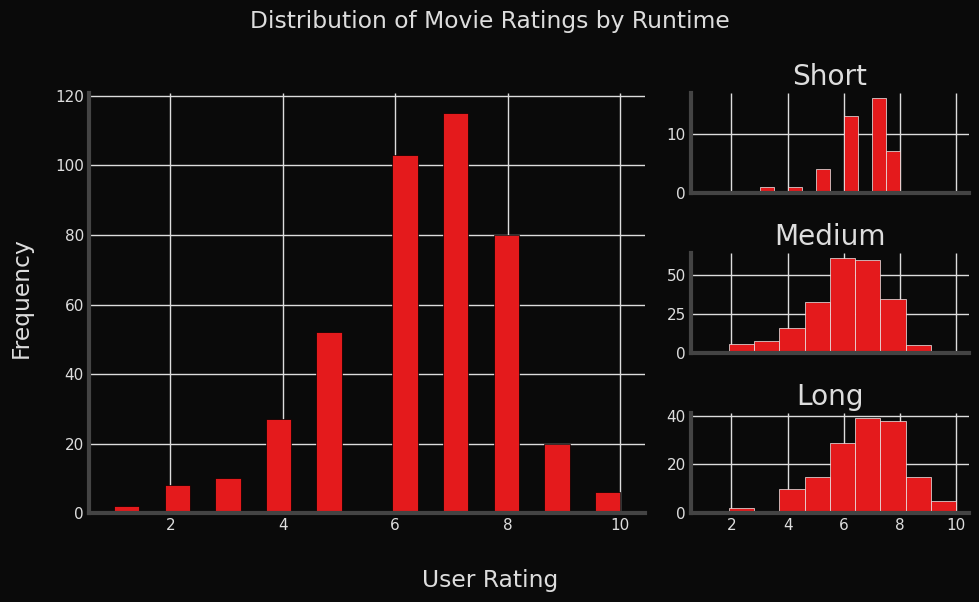

In [ ]:
fig, axs = plt.subplot_mosaic([['left', 'upper right'],
                               ['left', 'center right'],
                               ['left', 'lower right']],
                              figsize=(10, 6),
                              gridspec_kw={'width_ratios': [2, 1]}, sharex=True)
axs['left'].hist(df['User Rating'], bins=20, edgecolor='black')
axs['upper right'].hist(x='User Rating', data=df[df['Runtime Category'] == 'Short'])
axs['center right'].hist(x='User Rating', data=df[df['Runtime Category']== 'Medium'])
axs['lower right'].hist(x='User Rating', data=df[df['Runtime Category']== 'Long'])
# axs['left'].set_xlabel('User Rating')
# axs['left'].set_ylabel('Frequency')
# axs['left'].set_title('Distribution of Movie Ratings by Runtime')
axs['upper right'].set_title('Short')
axs['center right'].set_title('Medium')
axs['lower right'].set_title('Long')
fig.supxlabel('User Rating')
fig.supylabel('Frequency')
fig.suptitle('Distribution of Movie Ratings by Runtime')
plt.tight_layout()
plt.show()

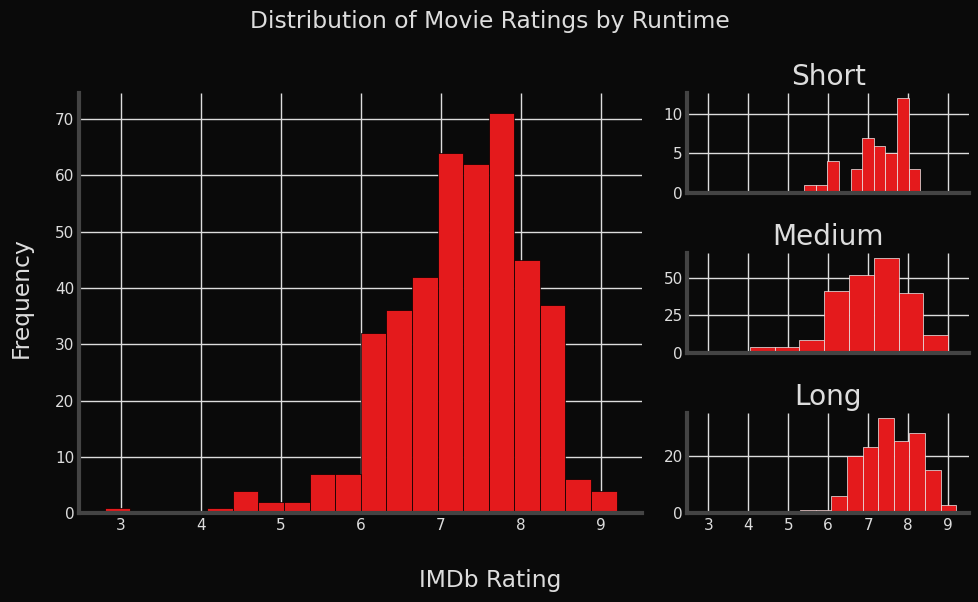

In [ ]:
fig, axs = plt.subplot_mosaic([['left', 'upper right'],
                               ['left', 'center right'],
                               ['left', 'lower right']],
                              figsize=(10, 6),
                              gridspec_kw={'width_ratios': [2, 1]}, sharex=True)
axs['left'].hist(df['IMDb Rating'], bins=20, edgecolor='black')
axs['upper right'].hist(x='IMDb Rating', data=df[df['Runtime Category'] == 'Short'])
axs['center right'].hist(x='IMDb Rating', data=df[df['Runtime Category']== 'Medium'])
axs['lower right'].hist(x='IMDb Rating', data=df[df['Runtime Category']== 'Long'])
# axs['left'].set_xlabel('IMDb Rating')
# axs['left'].set_ylabel('Frequency')
# axs['left'].set_title('Distribution of Movie Ratings by Runtime')
axs['upper right'].set_title('Short')
axs['center right'].set_title('Medium')
axs['lower right'].set_title('Long')
fig.supxlabel('IMDb Rating')
fig.supylabel('Frequency')
fig.suptitle('Distribution of Movie Ratings by Runtime')
plt.tight_layout()
plt.show()

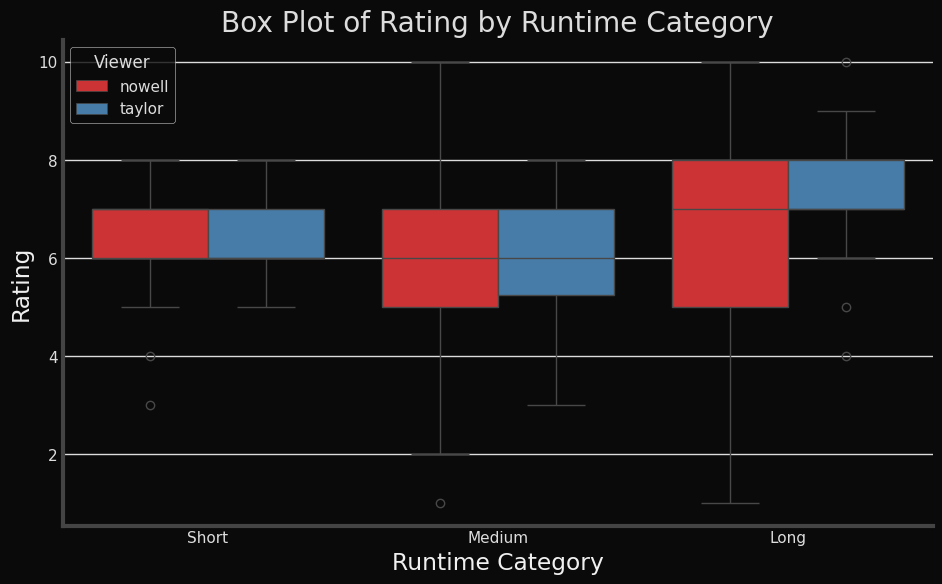

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Runtime Category', y='User Rating', data=df, hue='Viewer')
plt.title('Box Plot of Rating by Runtime Category')
plt.xlabel('Runtime Category')
plt.ylabel('Rating')
plt.show()

In [ ]:
# scipy.stats.mannwhitneyu
# scipy.stats.kruskal

## Summary/Findings


I rate lower than the IMDb average.